In [2]:
#directorio raiz donde esta el framework
%cd D:\tesis\scrpt pyton\interfaz_correccion\interfaz_correccion\efficient-kan\src\efficient_kan

D:\tesis\scrpt pyton\interfaz_correccion\interfaz_correccion\efficient-kan\src\efficient_kan


C:\Users\ferro\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import pandas as pd
import numpy as np
import os
import joblib
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR
from entmax import sparsemax, entmax15
from lion_pytorch import Lion
from kan import KANLinear, KAN
import shap
import lime
import lime.lime_tabular
# Configuración para usar la GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.preprocessing import LabelEncoder

In [22]:
# Establecer semillas para reproducibilidad
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:
# Cargar el dataset desde un archivo Excel
daf = pd.read_excel('D:\\tesis\\Modelo_extraccion_no\\dataset_extraccion_up_low_bimax.xlsx')
daf.columns

Index(['Paciente', 'Edad', 'Genero', 'Etnia', 'Apiñamiento sup',
       'Apiñamiento inf', 'Overbite', 'Overjet', 'SNA', 'SNB', 'ANB',
       'A-Macna', 'Pg-Macna', 'IMPA', 'SN-MP', 'SN-GoGn', 'Fh-Npog',
       'Ngo-GoMe', 'NS-SGn', 'U1-Sn', 'U1-PP', 'U1-NA(mm)', 'U1-Na(°)',
       'L1-NB(mm)', 'L1-NB(°)', 'U1-L1', 'L1-Apog', 'U1-Apog', 'Sts-Sti',
       'UL-E-Line', 'LL-E-Line', 'UlSn-SnPmn', 'LLB'-B'Pog'',
       'discrepancia total inferior', 'discrepancia total superior',
       'Clasificación  esqueletica', 'Relación molar', 'Relación premolar',
       'Relacion canina', 'Clase real', 'Extraccion / no extraccion inf',
       'Extraccion / no extraccion sup', 'Extraccion tejidos blandos',
       'Extraccion / no extraccion', 'Tipo de extraccióin global'],
      dtype='object')

In [5]:
daf.drop(columns=["Extraccion / no extraccion inf","Extraccion / no extraccion sup", "Extraccion / no extraccion","Paciente","Extraccion tejidos blandos",'discrepancia total inferior', 'discrepancia total superior',"Clase real"],inplace=True)
daf

,Edad,Genero,Etnia,Apiñamiento sup,Apiñamiento inf,Overbite,Overjet,SNA,SNB,ANB,...,Sts-Sti,UL-E-Line,LL-E-Line,UlSn-SnPmn,LLB'-B'Pog',Clasificación esqueletica,Relación molar,Relación premolar,Relacion canina,Tipo de extraccióin global
0,39,F,afrocolombiana,-4.00,-16.0,5.945810,2.202145,84.573158,82.968865,-1.604293,...,0.220212,-4.876738,0.516159,88.976967,153.536996,Clase 3,clase 1,clase 1,clase 2,Extracción bima
1,29,F,meztizo,-2.50,-5.5,2.797421,1.165594,81.689042,76.753278,4.935764,...,0.233121,-4.594830,-1.478628,76.829501,150.843664,Clase 2,clase 1,clase 1,clase 1,Extracción bima
2,27,F,meztizo,-0.70,-0.4,-1.864948,0.233121,88.991416,88.257801,0.733615,...,0.233121,-3.142670,-2.029610,75.193551,132.754262,Clase 3,clase 3,clase 3,clase 3,No extracción
3,42,F,meztizo,4.69,-2.5,3.729886,2.098068,81.962304,77.149397,4.812907,...,0.000000,-4.233241,-2.474814,58.780804,136.972533,Clase 2,clase 2,clase 2,clase 2,No extracción
4,33,F,meztizo,7.17,-3.8,3.263663,1.165594,85.601294,80.637686,4.963608,...,0.233121,-1.258132,2.175378,75.805316,158.163527,Clase 2,clase 3,clase 3,clase 1,Extracción inf.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,40,M,meztizo,0.00,-1.0,-0.308762,-4.322586,85.785459,86.081896,0.296437,...,0.000000,-6.782278,-4.331714,64.730585,168.402454,Clase 3,clase 3,clase 3,clase 3,Extracción bima
496,23,M,meztizo,3.00,-2.0,2.778801,4.013824,81.468412,78.959218,2.509194,...,0.308762,-1.294142,-1.249473,86.513197,141.985936,Clase 2,clase 1,clase 1,clase 1,No extracción
497,19,M,meztizo,-6.00,-5.0,5.633917,3.442950,85.643270,80.706450,4.936821,...,0.938992,-3.556261,-0.994024,30.703272,138.691411,Clase 2,clase 2,clase 2,clase 2,No extracción
498,34,M,afrocolombiana,6.00,1.0,0.599442,-3.296960,85.662749,87.259750,7.077501,...,0.899167,1.513549,5.711739,95.258436,154.902959,Clase 2,clase 2,clase 2,clase 2,Extracción bima


In [6]:
daf["Tipo de extraccióin global"].value_counts()

Tipo de extraccióin global
No extracción      274
Extracción bima    196
Extracción inf.     17
Extracción sup.     13
Name: count, dtype: int64

In [7]:
LabelEncoder_1=LabelEncoder()
daf["Genero"]=LabelEncoder_1.fit_transform(daf["Genero"])
daf["Etnia"]=LabelEncoder_1.fit_transform(daf["Etnia"])
daf["Clasificación  esqueletica"]=LabelEncoder_1.fit_transform(daf["Clasificación  esqueletica"])
daf["Relación molar"]=LabelEncoder_1.fit_transform(daf["Relación molar"])
daf["Relacion canina"]=LabelEncoder_1.fit_transform(daf["Relacion canina"])
daf["Relación premolar"]=LabelEncoder_1.fit_transform(daf["Relación premolar"])

In [8]:
daf["Tipo de extraccióin global"].value_counts()

Tipo de extraccióin global
No extracción      274
Extracción bima    196
Extracción inf.     17
Extracción sup.     13
Name: count, dtype: int64

In [9]:
df= daf.copy()
df['Tipo de extraccióin global'] = df['Tipo de extraccióin global'].map({'Extracción bima': 1, 'No extracción': 0,"Extracción sup.":1,'Extracción inf.':1})

In [10]:
df["Tipo de extraccióin global"].value_counts()

Tipo de extraccióin global
0    274
1    226
Name: count, dtype: int64

In [11]:
Labels = df['Tipo de extraccióin global']
Features = df.drop(['Tipo de extraccióin global'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(Features, Labels, test_size=0.1, stratify=Labels, random_state=42)

In [12]:
# Guardar los conjuntos de datos de la extracción superiorsup
joblib.dump((X_train, y_train), 'D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')
joblib.dump((X_test, y_test), 'D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')

['D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl']

In [3]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')

# UNBALANCEdD ANY

In [87]:
X_train_unbalance= torch.tensor(X_train.values, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test.values, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

In [88]:
# Verificar el balance de las clases
unique_classes, class_counts = torch.unique(Y_train_unbalance, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f'Clase {cls.item()}: {count.item()} muestras')

Clase 0.0: 219 muestras
Clase 1.0: 181 muestras


In [89]:
Y_test_unbalance.dtype

torch.float32

## KAN

In [90]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [91]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Concatenar los conjuntos de entrenamiento y prueba
X = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

train_losses = []
val_losses = []
train_accuracies = []  # Lista para accuracies de entrenamiento
val_accuracies = []  # Lista para accuracies de validación
precisions = []
recalls = []
f1s = []
accuracys =[]
pos_weight = torch.tensor([len(y[y == 0]) / len(y[y == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 5  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_model_path = None

# Realizar la validación cruzada
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f'Fold {fold+1}')

    X_train_fold, X_val_fold = X[train_index], X[test_index]
    y_train_fold, y_val_fold = y[train_index], y[test_index]

    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(42))

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, generator=torch.Generator().manual_seed(42))

    best_val_loss = float('inf')  # Inicializar la mejor pérdida de validación
    epochs_no_improve = 0  # Contador de épocas sin mejora

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0  # Acumulador para accuracy de entrenamiento
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        # Guardar accuracy promedio de entrenamiento por época
        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs).squeeze()
                # Asegúrate de que 'outputs' tiene las mismas dimensiones que 'labels'
                if outputs.dim() == 0:  # Si el output es un escalar
                    outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
                elif outputs.dim() == 1 and labels.dim() == 2:
                    outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Calcular las métricas
        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100  # Convertir a porcentaje
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)
        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\any\\", f'efficientKan_anyex_fold_{fold+1}.pth'))
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        # Implementar EarlyStopping
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\any\\", f'efficientKan_anyex_fold_{fold+1}.pth')

# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(accuracy), np.std(accuracy))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")

Fold 1


100%|██████████| 13/13 [00:00<00:00, 50.42it/s, accuracy=0.812, loss=0.848, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1, Train Loss: 0.8054898381233215, Val Loss: 0.7721886038780212, Val Accuracy: 0.515625


100%|██████████| 13/13 [00:00<00:00, 48.99it/s, accuracy=0.562, loss=0.761, lr=0.0001]


Epoch 2, Train Loss: 0.7660117149353027, Val Loss: 0.7565210610628128, Val Accuracy: 0.515625


...

Epoch 75, Train Loss: 0.43552106389632594, Val Loss: 0.3779202252626419, Val Accuracy: 0.8203125


100%|██████████| 13/13 [00:00<00:00, 47.23it/s, accuracy=0.688, loss=0.482, lr=0.0001]


Epoch 76, Train Loss: 0.42585834860801697, Val Loss: 0.3904940336942673, Val Accuracy: 0.8203125


100%|██████████| 13/13 [00:00<00:00, 36.06it/s, accuracy=1, loss=0.245, lr=0.0001]   


Epoch 77, Train Loss: 0.41184065433648914, Val Loss: 0.4134281724691391, Val Accuracy: 0.828125
Early stopping triggered after 77 epochs.

Precisión: 85.00 ± 0.00%
F1-score: 77.47 ± 7.08%
Precisión (Precision): 78.74 ± 6.13%
Recall: 77.63 ± 6.20%

Best model saved at: D:\tesis\Modelo_extraccion_no\Extraccion_general\any\efficientKan_anyex_fold_5.pth


In [93]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")


Precisión: 0.74 ± 0.10%
F1-score: 77.47 ± 7.08%
Precisión (Precision): 78.74 ± 6.13%
Recall: 77.63 ± 6.20%

Best model saved at: D:\tesis\Modelo_extraccion_no\Extraccion_general\any\efficientKan_anyex_fold_5.pth


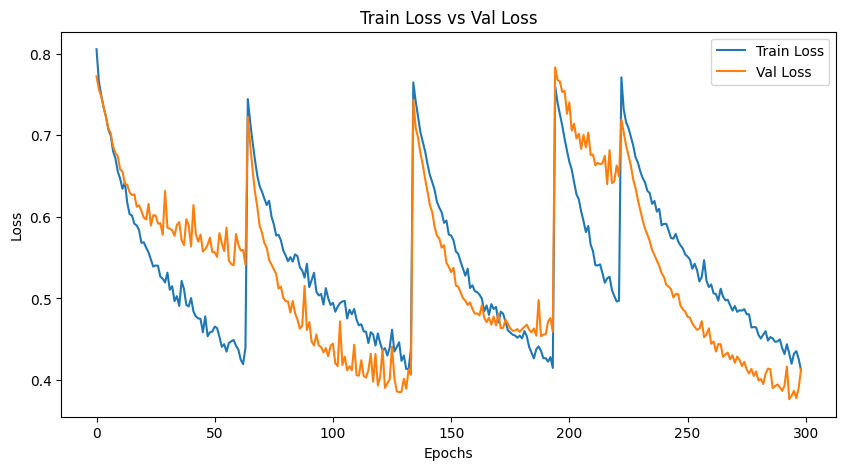

In [94]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['f1']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_anyunbalext_{scoring}.pkl"
    joblib.dump(best_model, model_path)

WARNING! The apex is not installed so fp16 is not available.
Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\qhoptim\pyt\qhadam.py:133: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha) (Trig

Steps	Train Err	Val Metric (error_rate)
100	0.7277	0.5167
200	0.6166	0.4333
300	0.6048	0.3333
400	0.4546	0.2667
500	0.345	0.25
600	0.3373	0.25
700	0.3878	0.2167
800	0.2411	0.15
900	0.1927	0.1167
1000	0.3018	0.1333
1100	0.2435	0.1167
1200	0.1848	0.1167
1300	0.1615	0.1
1400	0.2564	0.1167
1500	0.1617	0.1333
1600	0.0977	0.1333
1700	0.1646	0.1333
1800	0.1118	0.15
1900	0.1332	0.1333
2000	0.1036	0.1333
2100	0.1321	0.1333
2200	0.0972	0.1333
2300	0.1022	0.1333
2400	0.1998	0.1333
2500	0.1482	0.1333
BREAK. There is no improvment for 500 steps
Total training time: 68.0 seconds
Best step:  1300
Best Val Metric:  0.1
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation f1: 0.8801012938200483


In [95]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\any", "mejor_nodegam_extrac_any_unbal")
os.makedirs(best_model_path, exist_ok=True)

# Unir los conjuntos de entrenamiento y prueba
X_combined = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y_combined = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_combined.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_combined_df = pd.DataFrame(X_combined.cpu().numpy())
preprocessor.fit(X_combined_df, y_combined.cpu().numpy())
X_combined_trans = preprocessor.transform(X_combined_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_combined_trans = torch.tensor(X_combined_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 300,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 4
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_combined_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_losses = []
val_accuracies = []
f1s = []
precisions = []
recalls = []

best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_combined_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_combined_trans[train_index], X_combined_trans[val_index]
    y_train_fold, y_val_fold = y_combined[train_index], y_combined[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes)*100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}, F1-score: {f1}")

# Guardar el mejor modelo basado en F1-score
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    model = create_model(best_params)
    model.fit(pd.DataFrame(X_combined_trans.cpu().numpy()), y_combined.cpu().numpy())
    joblib.dump(model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")

Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6709	0.3833
200	0.677	0.2333
300	0.611	0.1667
400	0.4486	0.1667
500	0.4187	0.15
600	0.4143	0.1167
700	0.328	0.1
800	0.3292	0.1167
900	0.3478	0.1
1000	0.32	0.1
1100	0.4386	0.0833
1200	0.2957	0.0667
1300	0.1989	0.05
1400	0.3018	0.05
1500	0.2012	0.05
1600	0.1745	0.0667
1700	0.114	0.0667
1800	0.2096	0.0667
1900	0.1304	0.0667
2000	0.1475	0.05
2100	0.1964	0.05
2200	0.0924	0.05
2300	0.1395	0.05
2400	0.1357	0.05
2500	0.1371	0.05
BREAK. There is no improvment for 500 steps
Total training time: 67.3 seconds
Best step:  1300
Best Val Metric:  0.05
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 86.0, F1-score: 86.10227272727272
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.768	0.3667
200	0.5312	0.3
300	0.5895	0.2333
400	0.6293	0.2167
500	0.4248	0.2167
600	0.3496	0.2
700	0.2458	0.2
800	0.348	0.2
900	0.1706	0.1667
1000	0.2713	0.1
1100	0.2777	0.0833
1200	0.1894	0.05
1300	0.2106	0.05
1400	0.231	0.05
1500	0.1274	0.0667
1600	0.2528	0.0667
1700	0.0408	0.0667
1800	0.19	0.05
1900	0.1792	0.05
2000	0.1334	0.05
2100	0.1002	0.0667
2200	0.1225	0.05
2300	0.0869	0.05
2400	0.141	0.0667
2500	0.0625	0.0667
BREAK. There is no improvment for 500 steps
Total training time: 63.8 seconds
Best step:  1200
Best Val Metric:  0.05
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 86.0, F1-score: 85.97745571658615
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


...

Steps	Train Err	Val Metric (error_rate)
100	0.6969	0.45
200	0.5946	0.4
300	0.4841	0.2667
400	0.3779	0.2667
500	0.2951	0.2667
600	0.3155	0.25
700	0.2558	0.25
800	0.1669	0.2333
900	0.1515	0.2333
1000	0.1412	0.2167
1100	0.1563	0.2167
1200	0.1933	0.2167
1300	0.1275	0.2167
1400	0.1226	0.1667
1500	0.1162	0.1667
1600	0.1716	0.1333
1700	0.084	0.1333
1800	0.1365	0.1333
1900	0.0758	0.1333
2000	0.1563	0.1333
2100	0.1095	0.1333
2200	0.0426	0.1333
2300	0.135	0.1333
2400	0.2485	0.1333
2500	0.2595	0.1333
BREAK. There is no improvment for 500 steps
Total training time: 65.9 seconds
Best step:  1600
Best Val Metric:  0.13333333333333333
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 83.0, F1-score: 82.99147869674186
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.8521	0.3833
200	0.5921	0.2833
300	0.5181	0.2
400	0.4923	0.2
500	0.3674	0.2167
600	0.3008	0.2
700	0.2691	0.2167
800	0.3546	0.2333
900	0.1831	0.2
1000	0.2758	0.2
1100	0.2679	0.2
1200	0.1952	0.1833
1300	0.265	0.1667
1400	0.2324	0.1833
1500	0.1605	0.15
1600	0.1869	0.1667
1700	0.1533	0.15
1800	0.2539	0.1667
1900	0.0898	0.1667
2000	0.2199	0.1667
2100	0.167	0.1667
2200	0.2553	0.1667
2300	0.1212	0.1667
2400	0.1262	0.1667
2500	0.2139	0.1667
BREAK. There is no improvment for 500 steps
Total training time: 63.7 seconds
Best step:  1500
Best Val Metric:  0.15
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 92.0, F1-score: 92.02976436544026


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (500). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7032	0.44
200	0.6702	0.2933
300	0.591	0.24
400	0.5563	0.2
500	0.4008	0.1467
600	0.4978	0.1333
700	0.2606	0.12
800	0.4154	0.1067
900	0.3318	0.0933
1000	0.4407	0.1067
1100	0.1989	0.12
1200	0.2177	0.0933
1300	0.1877	0.0933
1400	0.2045	0.08
1500	0.1814	0.08
1600	0.1115	0.0533
1700	0.1664	0.0533
1800	0.1631	0.0667
1900	0.2151	0.0667
2000	0.2067	0.08
2100	0.067	0.08
2200	0.2856	0.08
2300	0.3001	0.08
2400	0.2331	0.08
2500	0.1368	0.08
BREAK. There is no improvment for 500 steps
Total training time: 66.4 seconds
Best step:  1600
Best Val Metric:  0.05333333333333334
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\any\mejor_nodegam_extrac_any_unbal\best_model_fold_5.pth


In [97]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')


Precisión: 86.80 ± 2.93%
F1-score: 86.82 ± 2.93%
Precisión (Precision): 87.00 ± 2.94%
Recall: 86.80 ± 2.93%


# UNbalancedd PCA

In [6]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train)
X_train_pca= pca.transform(X_train)
X_test_pca=pca.transform(X_test)

In [7]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)


## KAN

In [8]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [9]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Concatenar los conjuntos de entrenamiento y prueba
X = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

train_losses = []
val_losses = []
train_accuracies = []  # Lista para accuracies de entrenamiento
val_accuracies = []  # Lista para accuracies de validación
precisions = []
recalls = []
f1s = []
accuracys=[]

pos_weight = torch.tensor([len(y[y == 0]) / len(y[y == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 5  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_model_path = None

# Realizar la validación cruzada
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f'Fold {fold+1}')

    X_train_fold, X_val_fold = X[train_index], X[test_index]
    y_train_fold, y_val_fold = y[train_index], y[test_index]

    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(42))

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, generator=torch.Generator().manual_seed(42))

    best_val_loss = float('inf')  # Inicializar la mejor pérdida de validación
    epochs_no_improve = 0  # Contador de épocas sin mejora

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0  # Acumulador para accuracy de entrenamiento
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        # Guardar accuracy promedio de entrenamiento por época
        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                # Asegúrate de que 'outputs' tiene las mismas dimensiones que 'labels'
                if outputs.dim() == 0:  # Si el output es un escalar
                    outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
                elif outputs.dim() == 1 and labels.dim() == 2:
                    outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Calcular las métricas
        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100  # Convertir a porcentaje
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)
        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\pca\\", f'efficientKan_pcaext_fold_{fold+1}.pth'))
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        # Implementar EarlyStopping
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\pca\\", f'efficientKan_pcaext_fold_{fold+1}.pth')

# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")

Fold 1


100%|██████████| 13/13 [00:00<00:00, 29.61it/s, accuracy=0.5, loss=0.755, lr=0.0001]  


Epoch 1, Train Loss: 0.7504642789180462, Val Loss: 0.7340346723794937, Val Accuracy: 0.609375


100%|██████████| 13/13 [00:00<00:00, 49.06it/s, accuracy=0.562, loss=0.752, lr=0.0001]


Epoch 2, Train Loss: 0.7413262679026678, Val Loss: 0.7236835360527039, Val Accuracy: 0.609375


...

Epoch 50, Train Loss: 0.4400182801943559, Val Loss: 0.48772576078772545, Val Accuracy: 0.8515625


100%|██████████| 13/13 [00:00<00:00, 40.03it/s, accuracy=0.812, loss=0.531, lr=0.0001]


Epoch 51, Train Loss: 0.4423642066808847, Val Loss: 0.48575523495674133, Val Accuracy: 0.8515625


 92%|█████████▏| 12/13 [00:00<00:00, 45.92it/s, accuracy=0.781, loss=0.418, lr=0.0001]


KeyboardInterrupt: 

In [ ]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")


Precisión: 0.70 ± 0.12%
F1-score: 75.51 ± 5.79%
Precisión (Precision): 76.81 ± 5.54%
Recall: 75.50 ± 5.65%

Best model saved at: D:\tesis\Modelo_extraccion_no\Extraccion_general\pca\efficientKan_pcaext_fold_5.pth


## NODE_GAM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['f1']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_pcaunbalext_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7225	0.6
200	0.7009	0.5833
300	0.582	0.5
400	0.5309	0.4
500	0.4681	0.3667
600	0.4747	0.2833
700	0.4234	0.2333
800	0.4551	0.1833
900	0.4088	0.1667
1000	0.6399	0.1667
1100	0.2149	0.1667
1200	0.3143	0.15
1300	0.3852	0.15
1400	0.319	0.1333
1500	0.2758	0.1167
1600	0.202	0.1167
1700	0.2581	0.1167
1800	0.2353	0.1167
1900	0.3411	0.1167
2000	0.1429	0.1167
2100	0.3266	0.1333
2200	0.5215	0.1333
2300	0.3174	0.1167
2400	0.1583	0.1167
2500	0.2511	0.1167
BREAK. There is no improvment for 500 steps
Total training time: 70.6 seconds
Best step:  1500
Best Val Metric:  0.11666666666666667
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation f1: 0.8275206015583398


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\pca", "mejor_nodegam_ext_PCA_unBAL")
os.makedirs(best_model_path, exist_ok=True)

# Unir los conjuntos de entrenamiento y prueba
X_combined = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y_combined = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_combined.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_combined_df = pd.DataFrame(X_combined.cpu().numpy())
preprocessor.fit(X_combined_df, y_combined.cpu().numpy())
X_combined_trans = preprocessor.transform(X_combined_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_combined_trans = torch.tensor(X_combined_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_combined_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_losses = []
val_accuracies = []
f1s = []
precisions = []
recalls = []
accuracys =[]
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_combined_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_combined_trans[train_index], X_combined_trans[val_index]
    y_train_fold, y_val_fold = y_combined[train_index], y_combined[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes)*100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)
    
    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}, F1-score: {f1}")

# Guardar el mejor modelo basado en F1-score
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    model = create_model(best_params)
    model.fit(pd.DataFrame(X_combined_trans.cpu().numpy()), y_combined.cpu().numpy())
    joblib.dump(model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")

Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7513	0.6333
200	0.6914	0.55
300	0.6354	0.4333
400	0.6069	0.35
500	0.5178	0.2833
600	0.6145	0.1833
700	0.441	0.1667
800	0.4637	0.15
900	0.2757	0.1333
1000	0.4456	0.1167
1100	0.2258	0.1
1200	0.3177	0.1167
1300	0.502	0.1167
1400	0.3716	0.1
1500	0.3686	0.1
1600	0.2627	0.0667
1700	0.4051	0.0667
1800	0.3131	0.05
1900	0.3038	0.0667
2000	0.2839	0.0667
2100	0.3295	0.0333
2200	0.2144	0.0667
2300	0.2235	0.05
2400	0.3065	0.05
2500	0.3521	0.05
2600	0.275	0.0333
BREAK. There is no improvment for 500 steps
Total training time: 69.7 seconds
Best step:  2100
Best Val Metric:  0.03333333333333333
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 80.0, F1-score: 80.11423908608731
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6879	0.55
200	0.7042	0.45
300	0.6076	0.4333
400	0.5728	0.3667
500	0.5122	0.3667
600	0.4818	0.3167
700	0.4005	0.25
800	0.5144	0.2833
900	0.4218	0.3167
1000	0.4175	0.2833
1100	0.4486	0.2667
1200	0.3215	0.2667
1300	0.1999	0.2667
1400	0.399	0.2333
1500	0.3713	0.2667
1600	0.4734	0.25
1700	0.2361	0.2667
1800	0.4506	0.2667
1900	0.3124	0.25
2000	0.1922	0.25
2100	0.271	0.25
2200	0.2047	0.25
2300	0.1841	0.25
2400	0.1624	0.2333
2500	0.2552	0.2333
BREAK. There is no improvment for 500 steps
Total training time: 70.9 seconds
Best step:  1400
Best Val Metric:  0.23333333333333334
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 87.0, F1-score: 87.00651629072681
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


...

Steps	Train Err	Val Metric (error_rate)
100	0.7045	0.25
200	0.683	0.2333
300	0.6605	0.2
400	0.5988	0.1833
500	0.5351	0.1833
600	0.3392	0.1833
700	0.5797	0.1833
800	0.3024	0.15
900	0.3437	0.15
1000	0.3391	0.15
1100	0.3201	0.1167
1200	0.3444	0.1167
1300	0.2262	0.1167
1400	0.1932	0.1167
1500	0.2934	0.1333
1600	0.3062	0.1333
1700	0.2837	0.1333
1800	0.1842	0.15
1900	0.1459	0.15
2000	0.2598	0.15
2100	0.2469	0.15
2200	0.3167	0.15
2300	0.3033	0.15
2400	0.2592	0.15
2500	0.2842	0.15
BREAK. There is no improvment for 500 steps
Total training time: 68.0 seconds
Best step:  1100
Best Val Metric:  0.11666666666666667
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 81.0, F1-score: 81.005700570057
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6275	0.35
200	0.6788	0.3333
300	0.5572	0.2667
400	0.6435	0.25
500	0.5672	0.2667
600	0.4403	0.2333
700	0.3858	0.2167
800	0.331	0.1833
900	0.471	0.1667
1000	0.334	0.1667
1100	0.2699	0.15
1200	0.2739	0.1333
1300	0.4291	0.1333
1400	0.2969	0.1667
1500	0.2889	0.15
1600	0.4455	0.15
1700	0.2502	0.15
1800	0.3824	0.15
1900	0.3404	0.15
2000	0.2593	0.15
2100	0.2856	0.15
2200	0.3316	0.15
2300	0.3824	0.15
2400	0.4855	0.15
2500	0.2302	0.1667
BREAK. There is no improvment for 500 steps
Total training time: 74.2 seconds
Best step:  1200
Best Val Metric:  0.13333333333333333
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 91.0, F1-score: 91.04726598702503


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (500). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7309	0.4533
200	0.6439	0.4267
300	0.6281	0.44
400	0.5003	0.4133
500	0.5445	0.4133
600	0.4812	0.2933
700	0.4196	0.2667
800	0.3939	0.24
900	0.2711	0.2133
1000	0.29	0.2133
1100	0.425	0.1867
1200	0.3768	0.1867
1300	0.3514	0.1733
1400	0.4128	0.1733
1500	0.4101	0.1733
1600	0.4602	0.16
1700	0.2488	0.16
1800	0.3077	0.16
1900	0.311	0.16
2000	0.2397	0.1733
2100	0.5325	0.16
2200	0.2105	0.1733
2300	0.3071	0.16
2400	0.3396	0.1467
2500	0.2995	0.1467
2600	0.1691	0.1467
2700	0.2384	0.1467
2800	0.3812	0.1467
2900	0.2825	0.1467
BREAK. There is no improvment for 500 steps
Total training time: 81.3 seconds
Best step:  2400
Best Val Metric:  0.14666666666666667
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\pca\mejor_nodegam_ext_PCA_unBAL\best_model_fold_5.pth


In [ ]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')


Precisión: 84.40 ± 4.08%
F1-score: 84.43 ± 4.07%
Precisión (Precision): 84.58 ± 4.04%
Recall: 84.40 ± 4.08%


# Balancedd scaler

In [ ]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [ ]:
X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [ ]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [ ]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Concatenar los conjuntos de entrenamiento y prueba
X = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

train_losses = []
val_losses = []
train_accuracies = []  # Lista para accuracies de entrenamiento
val_accuracies = []  # Lista para accuracies de validación
precisions = []
recalls = []
f1s = []
accuracys=[]

pos_weight = torch.tensor([len(y[y == 0]) / len(y[y == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 5  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_model_path = None

# Realizar la validación cruzada
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f'Fold {fold+1}')

    X_train_fold, X_val_fold = X[train_index], X[test_index]
    y_train_fold, y_val_fold = y[train_index], y[test_index]

    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(42))

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, generator=torch.Generator().manual_seed(42))

    best_val_loss = float('inf')  # Inicializar la mejor pérdida de validación
    epochs_no_improve = 0  # Contador de épocas sin mejora

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0  # Acumulador para accuracy de entrenamiento
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        # Guardar accuracy promedio de entrenamiento por época
        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                if outputs.dim() == 0:  # Si el output es un escalar
                    outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
                elif outputs.dim() == 1 and labels.dim() == 2:
                    outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Calcular las métricas
        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100  # Convertir a porcentaje
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)
        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\scaler\\", f'efficientKan_scale_unbalext_fold_{fold+1}.pth'))
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        # Implementar EarlyStopping
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\scaler\\", f'efficientKan_scale_unbalext_fold_{fold+1}.pth')



Fold 1


100%|██████████| 13/13 [00:00<00:00, 46.51it/s, accuracy=0.812, loss=0.721, lr=0.0001]


Epoch 1, Train Loss: 0.7593098557912387, Val Loss: 0.7633416652679443, Val Accuracy: 0.515625


100%|██████████| 13/13 [00:00<00:00, 53.51it/s, accuracy=0.562, loss=0.756, lr=0.0001]


Epoch 2, Train Loss: 0.7596100614621089, Val Loss: 0.7625460773706436, Val Accuracy: 0.515625


...

Epoch 65, Train Loss: 0.1641947288925831, Val Loss: 0.21282730996608734, Val Accuracy: 0.9453125


100%|██████████| 13/13 [00:00<00:00, 41.90it/s, accuracy=1, loss=0.0722, lr=0.0001]   


Epoch 66, Train Loss: 0.15592374595311972, Val Loss: 0.21250805910676718, Val Accuracy: 0.9453125


100%|██████████| 13/13 [00:00<00:00, 52.99it/s, accuracy=0.938, loss=0.122, lr=0.0001]


Epoch 67, Train Loss: 0.153257215825411, Val Loss: 0.2158267260529101, Val Accuracy: 0.9453125
Early stopping triggered after 67 epochs.


In [ ]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")


Precisión: 83.52 ± 6.71%
F1-score: 83.37 ± 7.30%
Precisión (Precision): 84.68 ± 5.17%
Recall: 83.52 ± 6.71%

Best model saved at: D:\tesis\Modelo_extraccion_no\Extraccion_general\scaler\efficientKan_scale_unbalext_fold_5.pth


## NODE_GAM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['f1']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scaunbalext_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.3479	0.1833
200	0.3818	0.1667
300	0.2842	0.1333
400	0.388	0.1667
500	0.2684	0.1667
600	0.0459	0.1333
700	0.1279	0.1
800	0.0528	0.1
900	0.0572	0.1333
1000	0.0927	0.1333
1100	0.0311	0.1333
1200	0.0095	0.15
1300	0.0282	0.1333
1400	0.0255	0.1333
1500	0.0439	0.1333
1600	0.0182	0.15
1700	0.0044	0.1167
1800	0.0153	0.1167
1900	0.0197	0.1333
2000	0.0147	0.1333
2100	0.0051	0.1333
2200	0.0608	0.1333
2300	0.0121	0.1333
2400	0.0013	0.1167
2500	0.0215	0.1167
BREAK. There is no improvment for 500 steps
Total training time: 73.8 seconds
Best step:  700
Best Val Metric:  0.1
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation f1: 0.8910635837442944


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\scaler", "best_nodegam_model_scaunbal_ext")
os.makedirs(best_model_path, exist_ok=True)

# Unir los conjuntos de entrenamiento y prueba
X_combined = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y_combined = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_combined.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_combined_df = pd.DataFrame(X_combined.cpu().numpy())
preprocessor.fit(X_combined_df, y_combined.cpu().numpy())
X_combined_trans = preprocessor.transform(X_combined_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_combined_trans = torch.tensor(X_combined_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 300,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_combined_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_losses = []
val_accuracies = []
f1s = []
precisions = []
recalls = []
accuracys=[]
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_combined_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_combined_trans[train_index], X_combined_trans[val_index]
    y_train_fold, y_val_fold = y_combined[train_index], y_combined[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes)*100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)
    
    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}, F1-score: {f1}")

# Guardar el mejor modelo basado en F1-score
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    model = create_model(best_params)
    model.fit(pd.DataFrame(X_combined_trans.cpu().numpy()), y_combined.cpu().numpy())
    joblib.dump(model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")

Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5276	0.1167
200	0.3198	0.1333
300	0.5629	0.0833
400	0.1626	0.0667
500	0.2882	0.0667
600	0.0814	0.0667
700	0.2394	0.05
800	0.1588	0.05
900	0.063	0.05
1000	0.0638	0.05
1100	0.0577	0.05
1200	0.047	0.05
1300	0.0299	0.0667
1400	0.0429	0.0833
1500	0.0864	0.0667
1600	0.0747	0.05
1700	0.0254	0.0667
1800	0.0431	0.0667
1900	0.1071	0.0667
2000	0.0313	0.0667
2100	0.03	0.0333
2200	0.0691	0.0333
2300	0.0616	0.0333
2400	0.0395	0.0167
2500	0.0151	0.0167
2600	0.0107	0.0167
2700	0.0276	0.0167
2800	0.0195	0.0167
2900	0.017	0.0167
BREAK. There is no improvment for 500 steps
Total training time: 77.7 seconds
Best step:  2400
Best Val Metric:  0.016666666666666666
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 90.0, F1-score: 90.0
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stoppi

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5077	0.1833
200	0.2734	0.1833
300	0.3017	0.1833
400	0.1238	0.15
500	0.1436	0.15
600	0.1372	0.1333
700	0.0534	0.1167
800	0.0799	0.1333
900	0.0721	0.1167
1000	0.0584	0.1167
1100	0.056	0.1
1200	0.0341	0.1
1300	0.0171	0.1
1400	0.0187	0.1167
1500	0.0113	0.1
1600	0.0102	0.1
1700	0.0197	0.1
1800	0.0075	0.0833
1900	0.023	0.0667
2000	0.0068	0.0667
2100	0.0209	0.1
2200	0.0065	0.0833
2300	0.048	0.1167
2400	0.003	0.0833
2500	0.1106	0.0833
BREAK. There is no improvment for 500 steps
Total training time: 67.6 seconds
Best step:  1900
Best Val Metric:  0.06666666666666667
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 89.0, F1-score: 89.00990891802623
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


...

Steps	Train Err	Val Metric (error_rate)
100	0.6756	0.2833
200	0.2412	0.2833
300	0.2287	0.2167
400	0.2553	0.2167
500	0.1694	0.2
600	0.098	0.1833
700	0.082	0.1333
800	0.0736	0.1333
900	0.0186	0.1167
1000	0.0269	0.1333
1100	0.0358	0.1167
1200	0.0118	0.1167
1300	0.0296	0.1333
1400	0.013	0.1333
1500	0.0383	0.15
1600	0.0102	0.1667
1700	0.0128	0.15
1800	0.0358	0.15
1900	0.0152	0.1333
2000	0.044	0.1167
2100	0.1099	0.1333
2200	0.0243	0.1167
2300	0.0457	0.1
2400	0.0096	0.1167
2500	0.0146	0.1
2600	0.0032	0.1
2700	0.0285	0.1
2800	0.0149	0.1
BREAK. There is no improvment for 500 steps
Total training time: 75.4 seconds
Best step:  2300
Best Val Metric:  0.1
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 88.0, F1-score: 88.0048019207683
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.4635	0.2333
200	0.3051	0.1833
300	0.1739	0.1833
400	0.1952	0.2
500	0.0703	0.2
600	0.1831	0.2
700	0.0982	0.15
800	0.042	0.15
900	0.1458	0.1167
1000	0.0618	0.1333
1100	0.0138	0.1167
1200	0.0186	0.1
1300	0.0268	0.1167
1400	0.0011	0.1333
1500	0.0345	0.1167
1600	0.0378	0.1333
1700	0.0164	0.1
1800	0.0861	0.1167
1900	0.0292	0.1333
2000	0.0196	0.1333
2100	0.01	0.1333
2200	0.0035	0.1333
2300	0.0073	0.1333
2400	0.0106	0.1333
2500	0.026	0.1333
BREAK. There is no improvment for 500 steps
Total training time: 69.9 seconds
Best step:  1200
Best Val Metric:  0.1
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 93.0, F1-score: 93.01379811183733


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (500). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.4608	0.1733
200	0.4308	0.1067
300	0.1815	0.08
400	0.2341	0.0933
500	0.2293	0.08
600	0.1563	0.08
700	0.0427	0.1067
800	0.1168	0.0533
900	0.0226	0.08
1000	0.0808	0.0667
1100	0.06	0.08
1200	0.0259	0.08
1300	0.0212	0.08
1400	0.0207	0.08
1500	0.0241	0.0933
1600	0.1036	0.0667
1700	0.0684	0.08
1800	0.025	0.08
1900	0.1105	0.0667
2000	0.0251	0.0667
2100	0.0058	0.0667
2200	0.1242	0.08
2300	0.0342	0.08
2400	0.0672	0.08
2500	0.0683	0.08
BREAK. There is no improvment for 500 steps
Total training time: 66.7 seconds
Best step:  800
Best Val Metric:  0.05333333333333334
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\scaler\best_nodegam_model_scaunbal_ext\best_model_fold_5.pth


In [ ]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')


Precisión: 89.40 ± 2.06%
F1-score: 89.40 ± 2.07%
Precisión (Precision): 89.46 ± 2.06%
Recall: 89.40 ± 2.06%


# BALANCEDD PCA_SCALER

In [ ]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [ ]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

In [ ]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [ ]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [ ]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Concatenar los conjuntos de entrenamiento y prueba
X = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

train_losses = []
val_losses = []
train_accuracies = []  # Lista para accuracies de entrenamiento
val_accuracies = []  # Lista para accuracies de validación
precisions = []
recalls = []
f1s = []
accuracys=[]

pos_weight = torch.tensor([len(y[y == 0]) / len(y[y == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 5  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_model_path = None

# Realizar la validación cruzada
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f'Fold {fold+1}')

    X_train_fold, X_val_fold = X[train_index], X[test_index]
    y_train_fold, y_val_fold = y[train_index], y[test_index]

    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(42))

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, generator=torch.Generator().manual_seed(42))

    best_val_loss = float('inf')  # Inicializar la mejor pérdida de validación
    epochs_no_improve = 0  # Contador de épocas sin mejora

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0  # Acumulador para accuracy de entrenamiento
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        # Guardar accuracy promedio de entrenamiento por época
        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                if outputs.dim() == 0:  # Si el output es un escalar
                    outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
                elif outputs.dim() == 1 and labels.dim() == 2:
                    outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Calcular las métricas
        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100  # Convertir a porcentaje
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)
        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\pca_scaler\\", f'efficientKan_scale_ pca_scaunext_fold_{fold+1}.pth'))
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        # Implementar EarlyStopping
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\pca_scaler\\", f'efficientKan_scale_ pca_scaunext_fold_{fold+1}.pth')

# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")

Fold 1


100%|██████████| 13/13 [00:00<00:00, 45.80it/s, accuracy=0.812, loss=0.72, lr=0.0001] 


Epoch 1, Train Loss: 0.7599636591397799, Val Loss: 0.7645101249217987, Val Accuracy: 0.515625


100%|██████████| 13/13 [00:00<00:00, 47.05it/s, accuracy=0.562, loss=0.757, lr=0.0001]


Epoch 2, Train Loss: 0.7605661016244155, Val Loss: 0.7639592587947845, Val Accuracy: 0.515625


...

Epoch 89, Train Loss: 0.20085861935065344, Val Loss: 0.25649094209074974, Val Accuracy: 0.8984375


100%|██████████| 13/13 [00:00<00:00, 48.70it/s, accuracy=0.875, loss=0.205, lr=0.0001]


Epoch 90, Train Loss: 0.19689829360980254, Val Loss: 0.2567876633256674, Val Accuracy: 0.8984375


100%|██████████| 13/13 [00:00<00:00, 39.54it/s, accuracy=0.938, loss=0.164, lr=0.0001]


Epoch 91, Train Loss: 0.18975095049693033, Val Loss: 0.2576113399118185, Val Accuracy: 0.8984375
Early stopping triggered after 91 epochs.

Precisión: 79.78 ± 6.65%
F1-score: 79.49 ± 7.78%
Precisión (Precision): 81.82 ± 6.18%
Recall: 79.78 ± 6.65%

Best model saved at: D:\tesis\Modelo_extraccion_no\Extraccion_general\pca_scaler\efficientKan_scale_ pca_scaunext_fold_5.pth


In [ ]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")


Precisión: 79.78 ± 6.65%
F1-score: 79.49 ± 7.78%
Precisión (Precision): 81.82 ± 6.18%
Recall: 79.78 ± 6.65%

Best model saved at: D:\tesis\Modelo_extraccion_no\Extraccion_general\pca_scaler\efficientKan_scale_ pca_scaunext_fold_5.pth


## NODE_GAM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['f1']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scapcaunbalext_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6961	0.5
200	0.5081	0.3333
300	0.3274	0.1833
400	0.19	0.1167
500	0.2129	0.1167
600	0.2564	0.1
700	0.1495	0.1167
800	0.1461	0.1333
900	0.0845	0.1333
1000	0.0897	0.1333
1100	0.0581	0.15
1200	0.0911	0.15
1300	0.0519	0.1333
1400	0.0981	0.15
1500	0.0345	0.15
1600	0.0401	0.15
1700	0.0392	0.15
1800	0.0628	0.15
1900	0.1243	0.15
2000	0.0812	0.1333
2100	0.031	0.1333
2200	0.0346	0.1333
2300	0.0297	0.15
2400	0.0139	0.1333
2500	0.0566	0.1333
BREAK. There is no improvment for 500 steps
Total training time: 69.1 seconds
Best step:  600
Best Val Metric:  0.1
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation f1: 0.8961478113927205


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\PCA_scaler", "mejor_nodegam_scaler_pca_unbalext")
os.makedirs(best_model_path, exist_ok=True)

# Unir los conjuntos de entrenamiento y prueba
X_combined = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y_combined = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_combined.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_combined_df = pd.DataFrame(X_combined.cpu().numpy())
preprocessor.fit(X_combined_df, y_combined.cpu().numpy())
X_combined_trans = preprocessor.transform(X_combined_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_combined_trans = torch.tensor(X_combined_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 100,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_combined_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_losses = []
val_accuracies = []
f1s = []
precisions = []
recalls = []

best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_combined_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_combined_trans[train_index], X_combined_trans[val_index]
    y_train_fold, y_val_fold = y_combined[train_index], y_combined[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes)*100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}, F1-score: {f1}")

# Guardar el mejor modelo basado en F1-score
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    model = create_model(best_params)
    model.fit(pd.DataFrame(X_combined_trans.cpu().numpy()), y_combined.cpu().numpy())
    joblib.dump(model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")

Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6497	0.2833
200	0.5068	0.2167
300	0.3155	0.15
400	0.238	0.1333
500	0.1382	0.1333
600	0.1583	0.0667
700	0.1811	0.0667
800	0.1072	0.0667
900	0.0382	0.05
1000	0.1435	0.0667
1100	0.1028	0.0833
1200	0.1784	0.0667
1300	0.1121	0.0667
1400	0.1149	0.0667
1500	0.0438	0.0667
1600	0.1162	0.0833
1700	0.2122	0.0667
1800	0.1224	0.0667
1900	0.3139	0.0667
2000	0.1522	0.0667
2100	0.1187	0.05
2200	0.0457	0.0667
2300	0.1292	0.05
2400	0.1399	0.05
2500	0.0651	0.05
BREAK. There is no improvment for 500 steps
Total training time: 73.3 seconds
Best step:  900
Best Val Metric:  0.05
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 83.0, F1-score: 83.13882447827402
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6159	0.5
200	0.4504	0.35
300	0.3239	0.2667
400	0.279	0.2667
500	0.2024	0.2167
600	0.1255	0.2167
700	0.1418	0.1833
800	0.0587	0.1667
900	0.1591	0.1333
1000	0.1812	0.15
1100	0.047	0.1333
1200	0.0882	0.1167
1300	0.0775	0.1333
1400	0.0396	0.1333
1500	0.0949	0.1167
1600	0.0928	0.1333
1700	0.0496	0.1167
1800	0.0456	0.1
1900	0.1182	0.1333
2000	0.0374	0.15
2100	0.0779	0.1333
2200	0.0247	0.1167
2300	0.1081	0.1167
2400	0.0459	0.1
2500	0.0279	0.1
BREAK. There is no improvment for 500 steps
Total training time: 73.7 seconds
Best step:  1800
Best Val Metric:  0.1
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 88.0, F1-score: 88.00960384153662
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


...

Steps	Train Err	Val Metric (error_rate)
100	0.6865	0.4167
200	0.525	0.3
300	0.3249	0.15
400	0.1284	0.1167
500	0.0872	0.0833
600	0.1254	0.1333
700	0.1434	0.1667
800	0.0947	0.1333
900	0.0562	0.1833
1000	0.1032	0.1667
1100	0.0692	0.1667
1200	0.076	0.2
1300	0.042	0.1667
1400	0.1025	0.15
1500	0.0203	0.15
1600	0.0417	0.1667
1700	0.0537	0.15
1800	0.1617	0.15
1900	0.0821	0.2
2000	0.0853	0.2
2100	0.137	0.1667
2200	0.0541	0.1667
2300	0.0519	0.1667
2400	0.0088	0.1667
2500	0.0401	0.15
BREAK. There is no improvment for 500 steps
Total training time: 73.2 seconds
Best step:  500
Best Val Metric:  0.08333333333333333
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 79.0, F1-score: 79.00630063006301
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (400). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6724	0.2333
200	0.5749	0.15
300	0.4579	0.1333
400	0.2309	0.1333
500	0.1281	0.1333
600	0.2472	0.1333
700	0.1851	0.1333
800	0.1689	0.1333
900	0.1664	0.1667
1000	0.0787	0.15
1100	0.0445	0.15
1200	0.07	0.1333
1300	0.0842	0.1333
1400	0.1297	0.1667
1500	0.0518	0.1833
1600	0.0726	0.1667
1700	0.0807	0.1667
1800	0.1136	0.15
1900	0.0617	0.1667
2000	0.0437	0.1667
2100	0.0608	0.1667
2200	0.1253	0.1667
2300	0.052	0.1667
2400	0.0422	0.1333
2500	0.0179	0.1333
BREAK. There is no improvment for 500 steps
Total training time: 73.3 seconds
Best step:  300
Best Val Metric:  0.13333333333333333
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 84.0, F1-score: 83.73230373230373


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (500). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7265	0.4
200	0.5813	0.2533
300	0.3061	0.2133
400	0.2152	0.1333
500	0.1445	0.0933
600	0.09	0.1067
700	0.1006	0.08
800	0.1763	0.08
900	0.0884	0.1067
1000	0.0415	0.1067
1100	0.0718	0.12
1200	0.128	0.1333
1300	0.1049	0.12
1400	0.0097	0.12
1500	0.0736	0.1067
1600	0.0471	0.1067
1700	0.1257	0.0933
1800	0.1331	0.1067
1900	0.1486	0.0933
2000	0.0525	0.0933
2100	0.1428	0.1067
2200	0.0678	0.12
2300	0.0237	0.12
2400	0.0558	0.12
2500	0.1193	0.1333
BREAK. There is no improvment for 500 steps
Total training time: 73.7 seconds
Best step:  700
Best Val Metric:  0.08
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\PCA_scaler\mejor_nodegam_scaler_pca_unbalext\best_model_fold_2.pth


In [ ]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')


Precisión: 83.80 ± 2.93%
F1-score: 83.77 ± 2.91%
Precisión (Precision): 84.25 ± 2.94%
Recall: 83.80 ± 2.93%


# desd aqui para abajo son los modelos entrenados ultima versión

# UNBALANCED ANY

In [18]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')

In [19]:
X_train_unbalance= torch.tensor(X_train.values, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test.values, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

In [20]:
# Verificar el balance de las clases
unique_classes, class_counts = torch.unique(Y_train_unbalance, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f'Clase {cls.item()}: {count.item()} muestras')

Clase 0.0: 247 muestras
Clase 1.0: 203 muestras


In [21]:
Y_test_unbalance.dtype

torch.float32

## KAN

In [22]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [23]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\any\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")


Fold 1


100%|██████████| 12/12 [00:00<00:00, 58.03it/s, accuracy=0.5, loss=0.731, lr=0.0001] 


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\any\best_model.pth con val_loss: 0.7535951733589172
Epoch 1, Train Loss: 0.7770709196726481, Val Loss: 0.7535951733589172, Val Accuracy: 0.4815705219904582


100%|██████████| 12/12 [00:00<00:00, 45.71it/s, accuracy=0.75, loss=0.682, lr=0.0001] 


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\any\best_model.pth con val_loss: 0.7258257468541464
Epoch 2, Train Loss: 0.7174411714076996, Val Loss: 0.7258257468541464, Val Accuracy: 0.4815705219904582


...

Epoch 8, Train Loss: 0.6669768591721853, Val Loss: 0.6527552803357443, Val Accuracy: 0.6995192368825277


100%|██████████| 12/12 [00:00<00:00, 56.37it/s, accuracy=0.625, loss=0.558, lr=0.0001]


Epoch 9, Train Loss: 0.6498305300871531, Val Loss: 0.6409248113632202, Val Accuracy: 0.7379807829856873


100%|██████████| 12/12 [00:00<00:00, 54.97it/s, accuracy=0.375, loss=0.629, lr=0.0001]


Epoch 10, Train Loss: 0.6419913868109385, Val Loss: 0.6370470523834229, Val Accuracy: 0.7564102609952291
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 74.0%, F1-score: 73.78081091930952%, Precision: 76.56666666666666%, Recall: 74.0%


In [24]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 72.17 ± 5.79%
F1-score: 71.50 ± 7.58%
Precisión (Precision): 74.75 ± 4.51%
Recall: 72.17 ± 5.79%

Métricas del Conjunto de Prueba:
Precisión: 79.20 ± 2.99%
F1-score: 79.12 ± 3.05%
Precisión (Precision): 79.90 ± 2.37%
Recall: 79.20 ± 2.99%


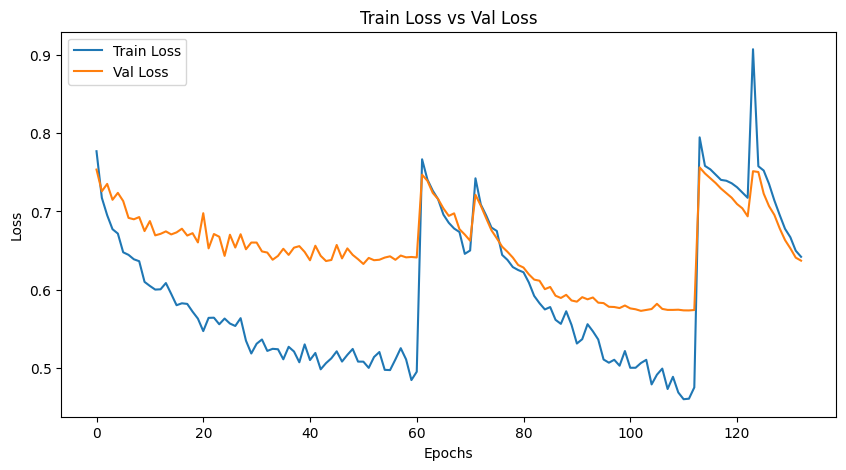

In [25]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gamm"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\any")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 300,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 4
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")

Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (500) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.8281	0.4259
200	0.6319	0.3148
300	0.5094	0.3148
400	0.4385	0.2037
500	0.3906	0.1852
600	0.2161	0.1852
700	0.3069	0.1667
800	0.2275	0.1852
900	0.2637	0.1667
1000	0.1223	0.1481
1100	0.2296	0.1481
1200	0.1586	0.1296
1300	0.2064	0.1111
1400	0.1123	0.0741
1500	0.1988	0.0741
1600	0.1213	0.0556
1700	0.0994	0.0556
1800	0.2266	0.0741
1900	0.1356	0.0741
2000	0.1111	0.0741
2100	0.2012	0.0741
2200	0.059	0.0741
2300	0.0887	0.0741
2400	0.3204	0.0741
2500	0.0764	0.0741
BREAK. There is no improvment for 500 steps
Total training time: 57.0 seconds
Best step:  1600
Best Val Metric:  0.05555555555555555
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 90.0%, F1-score: 90.00370416100752%, Test accuracy: 82.0%, Test F1-score: 81.84577723378213%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.8092	0.5
200	0.6325	0.3889
300	0.6473	0.2407
400	0.3901	0.2037
500	0.39	0.1852
600	0.3497	0.1852
700	0.2231	0.1852
800	0.2165	0.1852
900	0.2724	0.2037
1000	0.159	0.1667
1100	0.1869	0.1481
1200	0.5074	0.1111
1300	0.1113	0.0926
1400	0.3464	0.0556
1500	0.3604	0.0556
1600	0.1072	0.0556
1700	0.1655	0.0556
1800	0.1509	0.0556
1900	0.0726	0.0556
2000	0.1179	0.0556
2100	0.1601	0.0556
2200	0.1132	0.0556
2300	0.0876	0.0556
2400	0.1099	0.0741
2500	0.2273	0.0741
BREAK. There is no improvment for 500 steps
Total training time: 59.6 seconds
Best step:  1400
Best Val Metric:  0.05555555555555555
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 85.55555555555556%, F1-score: 85.76630502556428%, Test accuracy: 90.0%, Test F1-score: 89.97979797979798%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropou

...

Steps	Train Err	Val Metric (error_rate)
100	0.7778	0.4074
200	0.4785	0.2963
300	0.5609	0.2593
400	0.7112	0.1852
500	0.3915	0.1852
600	0.4721	0.1852
700	0.3808	0.2222
800	0.377	0.2037
900	0.2412	0.2037
1000	0.1987	0.1481
1100	0.5318	0.1481
1200	0.2118	0.1111
1300	0.1218	0.0741
1400	0.1865	0.0741
1500	0.173	0.0556
1600	0.0798	0.0556
1700	0.0714	0.0556
1800	0.3822	0.0741
1900	0.148	0.0926
2000	0.1914	0.1111
2100	0.2743	0.1296
2200	0.1109	0.1111
2300	0.1192	0.1111
2400	0.1239	0.0926
2500	0.2002	0.0926
BREAK. There is no improvment for 500 steps
Total training time: 55.3 seconds
Best step:  1500
Best Val Metric:  0.05555555555555555
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 94.44444444444444%, F1-score: 94.38398839243801%, Test accuracy: 90.0%, Test F1-score: 89.91432068543452%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dro

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5985	0.4074
200	0.6536	0.3519
300	0.5238	0.3148
400	0.4079	0.2963
500	0.3285	0.2407
600	0.3142	0.2037
700	0.2682	0.1667
800	0.8598	0.1481
900	0.3493	0.1667
1000	0.2623	0.1296
1100	0.175	0.1296
1200	0.1804	0.1296
1300	0.1774	0.1296
1400	0.1104	0.1296
1500	0.1407	0.1296
1600	0.0793	0.1296
1700	0.141	0.0926
1800	0.1669	0.1111
1900	0.1464	0.1111
2000	0.1797	0.0926
2100	0.0831	0.1111
2200	0.1429	0.1111
2300	0.2804	0.1111
2400	0.1343	0.1111
2500	0.0625	0.1111
BREAK. There is no improvment for 500 steps
Total training time: 55.4 seconds
Best step:  1700
Best Val Metric:  0.09259259259259259
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 86.66666666666667%, F1-score: 86.7%, Test accuracy: 90.0%, Test F1-score: 89.91432068543452%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7779	0.6176
200	0.6902	0.3971
300	0.6007	0.3382
400	0.4961	0.2206
500	0.5246	0.1912
600	0.4542	0.1618
700	0.3278	0.1618
800	0.3452	0.1324
900	0.2043	0.1324
1000	0.1839	0.1176
1100	0.2443	0.1176
1200	0.3292	0.1029
1300	0.3129	0.1176
1400	0.3811	0.1176
1500	0.2637	0.1029
1600	0.1098	0.1029
1700	0.1044	0.0882
1800	0.1615	0.0882
1900	0.1233	0.0882
2000	0.1511	0.0882
2100	0.1136	0.1029
2200	0.1253	0.0882
2300	0.2483	0.0735
2400	0.1495	0.0735
2500	0.1347	0.0735
2600	0.3584	0.0735
2700	0.0869	0.0735
2800	0.2237	0.0735
BREAK. There is no improvment for 500 steps
Total training time: 61.4 seconds
Best step:  2300
Best Val Metric:  0.07352941176470588
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\any\best_model_fold_4.pth


In [27]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.11 ± 3.10%
F1-score: 89.15 ± 3.02%
Precisión (Precision): 90.10 ± 2.67%
Recall: 89.11 ± 3.10%

Métricas del Conjunto de Prueba:
Precisión: 88.00 ± 3.10%
F1-score: 87.90 ± 3.13%
Precisión (Precision): 88.44 ± 3.13%
Recall: 88.00 ± 3.10%


# UNbalanced PCA

In [28]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')

In [29]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train)
X_train_pca= pca.transform(X_train)
X_test_pca=pca.transform(X_test)

In [30]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)


## KAN

In [31]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [32]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\pca\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 53.90it/s, accuracy=0.75, loss=0.71, lr=0.0001]  


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\pca\best_model.pth con val_loss: 0.765111247698466
Epoch 1, Train Loss: 0.7503152936697006, Val Loss: 0.765111247698466, Val Accuracy: 0.4815705219904582


100%|██████████| 12/12 [00:00<00:00, 53.46it/s, accuracy=0.5, loss=0.746, lr=0.0001] 


...

Epoch 8, Train Loss: 0.6984583338101705, Val Loss: 0.7176419099171957, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 57.18it/s, accuracy=0.625, loss=0.559, lr=0.0001]


Epoch 9, Train Loss: 0.6756109197934469, Val Loss: 0.714621365070343, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 47.49it/s, accuracy=0.375, loss=0.906, lr=0.0001]


Epoch 10, Train Loss: 0.6908067911863327, Val Loss: 0.7119991580645243, Val Accuracy: 0.5600961645444235
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 72.0%, F1-score: 71.30000000000001%, Precision: 72.81283422459893%, Recall: 72.0%


In [33]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 70.36 ± 6.18%
F1-score: 70.17 ± 6.91%
Precisión (Precision): 74.47 ± 5.62%
Recall: 70.36 ± 6.18%

Métricas del Conjunto de Prueba:
Precisión: 77.60 ± 4.80%
F1-score: 77.23 ± 5.23%
Precisión (Precision): 78.13 ± 4.20%
Recall: 77.60 ± 4.80%


## NODE_GAM

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gamm"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\PCA")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}



# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (500) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Steps	Train Err	Val Metric (error_rate)
100	0.6745	0.5926
200	0.6509	0.4259
300	0.5918	0.3333
400	0.452	0.2963
500	0.5015	0.2593
600	0.5335	0.2222
700	0.354	0.1667
800	0.2619	0.1667
900	0.5407	0.1111
1000	0.5814	0.1111
1100	0.2492	0.1111
1200	0.2404	0.1111
1300	0.3558	0.1481
1400	0.2523	0.1481
1500	0.216	0.1296
1600	0.2905	0.1111
1700	0.3161	0.1111
1800	0.2648	0.1296
1900	0.5607	0.1111
2000	0.1577	0.1111
2100	0.2959	0.1111
2200	0.3944	0.1296
2300	0.426	0.1296
2400	0.3045	0.1111
2500	0.2653	0.1111
BREAK. There is no improvment for 500 steps
Total training time: 57.3 seconds
Best step:  900
Best Val Metric:  0.1111111111111111
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 78.88888888888889%, F1-score: 78.5808

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7281	0.7778
200	0.6804	0.6852
300	0.7823	0.5
400	0.5393	0.4444
500	0.6387	0.4444
600	0.4901	0.4259
700	0.3991	0.3519
800	0.3974	0.2963
900	0.5584	0.2963
1000	0.2603	0.2778
1100	0.3046	0.2778
1200	0.2967	0.2778
1300	0.2738	0.2593
1400	0.2756	0.2407
1500	0.1939	0.2407
1600	0.5997	0.2222
1700	0.3781	0.2222
1800	0.2963	0.2222
1900	0.4994	0.2407
2000	0.2434	0.2407
2100	0.4686	0.2407
2200	0.3072	0.2407
2300	0.2847	0.2407
2400	0.2145	0.2407
2500	0.5751	0.2407
BREAK. There is no improvment for 500 steps
Total training time: 57.0 seconds
Best step:  1600
Best Val Metric:  0.2222222222222222
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 81.11111111111111%, F1-score: 81.31666168793298%, Test accuracy: 84.0%, Test F1-score: 84.0%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'e

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.712	0.5
200	0.6819	0.4815
300	0.5904	0.4074
400	0.5589	0.2778
500	0.487	0.2778
600	0.5818	0.2963
700	0.483	0.2037
800	0.5344	0.2222
900	0.5844	0.2037
1000	0.4439	0.2037
1100	0.4492	0.1667
1200	0.3431	0.1667
1300	0.558	0.2037
1400	0.64	0.1852
1500	0.3802	0.2037
1600	0.2745	0.2037
1700	0.5759	0.2037
1800	0.2749	0.2222
1900	0.3046	0.2037
2000	0.2988	0.2037
2100	0.3034	0.2222
2200	0.3047	0.2222
2300	0.307	0.2037
2400	0.4563	0.2037
2500	0.2652	0.2037
BREAK. There is no improvment for 500 steps
Total training time: 56.7 seconds
Best step:  1100
Best Val Metric:  0.16666666666666666
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 82.22222222222221%, F1-score: 81.9753086419753%, Test accuracy: 78.0%, Test F1-score: 76.89575289575289%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6037	0.4259
200	0.6337	0.3889
300	0.5865	0.3333
400	0.5174	0.2963
500	0.5046	0.2778
600	0.6105	0.2778
700	0.5232	0.2407
800	0.4193	0.2593
900	0.3435	0.2037
1000	0.3189	0.2037
1100	0.3184	0.1852
1200	0.6764	0.1852
1300	0.293	0.1852
1400	0.1499	0.1852
1500	0.2069	0.1852
1600	0.3527	0.1852
1700	0.26	0.1852
1800	0.2696	0.1852
1900	0.3985	0.1667
2000	0.3893	0.1852
2100	0.4657	0.1667
2200	0.4809	0.1667
2300	0.4445	0.1852
2400	0.2888	0.1667
2500	0.6899	0.1667
BREAK. There is no improvment for 500 steps
Total training time: 56.0 seconds
Best step:  1900
Best Val Metric:  0.16666666666666666
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 80.0%, F1-score: 80.08928571428571%, Test accuracy: 88.0%, Test F1-score: 88.0%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6941	0.4412
200	0.625	0.3824
300	0.657	0.3235
400	0.5625	0.2941
500	0.714	0.2353
600	0.5352	0.1765
700	0.4796	0.1618
800	0.5938	0.1618
900	0.3475	0.1324
1000	0.3395	0.1176
1100	0.4599	0.1176
1200	0.4962	0.1324
1300	0.2564	0.1324
1400	0.4034	0.1471
1500	0.2927	0.1471
1600	0.4337	0.1176
1700	0.391	0.1176
1800	0.3162	0.1176
1900	0.3213	0.1176
2000	0.4406	0.1029
2100	0.2416	0.0882
2200	0.311	0.1029
2300	0.3432	0.1176
2400	0.5003	0.1176
2500	0.4153	0.1176
2600	0.3669	0.1176
BREAK. There is no improvment for 500 steps
Total training time: 58.1 seconds
Best step:  2100
Best Val Metric:  0.08823529411764706
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\PCA\best_model_fold_4.pth


In [35]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 80.67 ± 1.13%
F1-score: 80.62 ± 1.18%
Precisión (Precision): 81.66 ± 0.59%
Recall: 80.67 ± 1.13%

Métricas del Conjunto de Prueba:
Precisión: 86.40 ± 4.96%
F1-score: 86.15 ± 5.32%
Precisión (Precision): 87.36 ± 4.07%
Recall: 86.40 ± 4.96%


# Balanced scaler

In [43]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')

In [44]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [45]:
X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [46]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [47]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\scaler\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


100%|██████████| 12/12 [00:00<00:00, 52.07it/s, accuracy=0.5, loss=0.768, lr=0.0001] 


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\scaler\best_model.pth con val_loss: 0.770005444685618
Epoch 1, Train Loss: 0.7582759410142899, Val Loss: 0.770005444685618, Val Accuracy: 0.4815705219904582


100%|██████████| 12/12 [00:00<00:00, 57.77it/s, accuracy=0.625, loss=0.748, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\scaler\best_model.pth con val_loss: 0.7693775097529093
Epoch 2, Train Loss: 0.7562376658121744, Val Loss: 0.7693775097529093, Val Accuracy: 0.4815705219904582


...

Epoch 8, Train Loss: 0.7526019265254339, Val Loss: 0.7493084867795309, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 53.95it/s, accuracy=0.625, loss=0.736, lr=0.0001]


Epoch 9, Train Loss: 0.7470532606045405, Val Loss: 0.7447826266288757, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 53.58it/s, accuracy=0.75, loss=0.705, lr=0.0001]


Epoch 10, Train Loss: 0.7393051236867905, Val Loss: 0.7381142377853394, Val Accuracy: 0.5600961645444235
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 90.0%, F1-score: 90.01200480192077%, Precision: 90.67307692307692%, Recall: 90.0%


In [48]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 78.92 ± 7.00%
F1-score: 78.53 ± 8.14%
Precisión (Precision): 81.27 ± 4.33%
Recall: 78.92 ± 7.00%

Métricas del Conjunto de Prueba:
Precisión: 88.80 ± 2.71%
F1-score: 88.74 ± 2.75%
Precisión (Precision): 89.74 ± 2.03%
Recall: 88.80 ± 2.71%


## NODE_GAM

In [50]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gamm"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\scaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 300,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


Using device: cuda


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (500) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(


Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5263	0.2963
200	0.2548	0.2222
300	0.0987	0.1481
400	0.0983	0.1111
500	0.0865	0.0926
600	0.1236	0.037
700	0.0813	0.037
800	0.0138	0.037
900	0.0255	0.037
1000	0.0361	0.037
1100	0.0608	0.037
1200	0.0216	0.037
1300	0.0134	0.037
1400	0.0236	0.0556
1500	0.0154	0.0556
1600	0.0703	0.0556
1700	0.003	0.0741
1800	0.0212	0.0556
1900	0.0209	0.0741
2000	0.0662	0.0741
2100	0.0018	0.0741
2200	0.0027	0.0741
2300	0.0034	0.0741
2400	0.0052	0.0741
2500	0.0174	0.0556
BREAK. There is no improvment for 500 steps
Total training time: 58.3 seconds
Best step:  600
Best Val Metric:  0.037037037037037035
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 90.0%, F1-score: 89.9938080495356%, Test accuracy: 88.0%, Test F1-score: 87.94155844155844%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_st

...

Steps	Train Err	Val Metric (error_rate)
100	0.6527	0.2037
200	0.3629	0.2222
300	0.2202	0.1481
400	0.1954	0.1111
500	0.205	0.1111
600	0.3648	0.1111
700	0.0442	0.1111
800	0.0225	0.1111
900	0.0411	0.1111
1000	0.2066	0.1111
1100	0.0194	0.1111
1200	0.0193	0.1296
1300	0.0054	0.1296
1400	0.0148	0.1111
1500	0.0099	0.1296
1600	0.0139	0.1111
1700	0.0144	0.1111
1800	0.0269	0.1111
1900	0.0028	0.1111
2000	0.0099	0.0926
2100	0.006	0.1111
2200	0.0377	0.0926
2300	0.0211	0.1111
2400	0.002	0.1111
2500	0.027	0.1111
BREAK. There is no improvment for 500 steps
Total training time: 58.8 seconds
Best step:  2000
Best Val Metric:  0.09259259259259259
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 87.77777777777777%, F1-score: 87.70793650793651%, Test accuracy: 86.0%, Test F1-score: 85.88004895960833%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropo

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5571	0.1852
200	0.6235	0.1296
300	0.1959	0.0741
400	0.2405	0.0741
500	0.0497	0.0926
600	0.0935	0.0926
700	0.128	0.1111
800	0.0486	0.1111
900	0.0221	0.1111
1000	0.0125	0.1296
1100	0.0101	0.0926
1200	0.0499	0.1111
1300	0.0212	0.1296
1400	0.0929	0.1296
1500	0.0383	0.1296
1600	0.0492	0.1296
1700	0.0164	0.1481
1800	0.1024	0.1296
1900	0.0031	0.1481
2000	0.0548	0.1296
2100	0.0085	0.1296
2200	0.0252	0.1296
2300	0.0512	0.1296
2400	0.0286	0.1296
2500	0.016	0.1296
BREAK. There is no improvment for 500 steps
Total training time: 58.1 seconds
Best step:  300
Best Val Metric:  0.07407407407407407
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 85.55555555555556%, F1-score: 85.60419004863449%, Test accuracy: 90.0%, Test F1-score: 89.97979797979798%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5269	0.1471
200	0.3654	0.1029
300	0.2122	0.1029
400	0.1538	0.0882
500	0.1484	0.1029
600	0.0788	0.1176
700	0.1208	0.0882
800	0.0503	0.1029
900	0.0322	0.0882
1000	0.061	0.1324
1100	0.0618	0.1176
1200	0.0158	0.1324
1300	0.0425	0.1324
1400	0.0286	0.1176
1500	0.0233	0.1471
1600	0.0187	0.1618
1700	0.0032	0.1324
1800	0.0419	0.1324
1900	0.064	0.1471
2000	0.0361	0.1324
2100	0.0822	0.1324
2200	0.0361	0.1324
2300	0.0558	0.1324
2400	0.0081	0.1324
2500	0.0151	0.1176
BREAK. There is no improvment for 500 steps
Total training time: 57.4 seconds
Best step:  400
Best Val Metric:  0.08823529411764706
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\scaler\best_model_fold_3.pth


In [51]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 88.00 ± 2.27%
F1-score: 88.04 ± 2.21%
Precisión (Precision): 88.57 ± 1.96%
Recall: 88.00 ± 2.27%

Métricas del Conjunto de Prueba:
Precisión: 87.60 ± 1.50%
F1-score: 87.55 ± 1.52%
Precisión (Precision): 87.72 ± 1.43%
Recall: 87.60 ± 1.50%


# BALANCED PCA_SCALER

In [52]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')

In [53]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [54]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

In [55]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [56]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [57]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\pca_scaler\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")
   

Fold 1


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 46.82it/s, accuracy=0.5, loss=0.769, lr=0.0001]  


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\pca_scaler\best_model.pth con val_loss: 0.7707568804423014
Epoch 1, Train Loss: 0.7586496373017629, Val Loss: 0.7707568804423014, Val Accuracy: 0.4815705219904582


100%|██████████| 12/12 [00:00<00:00, 55.70it/s, accuracy=0.625, loss=0.748, lr=0.0001]


...

Epoch 8, Train Loss: 0.7454971422751745, Val Loss: 0.7414844234784445, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 46.75it/s, accuracy=0.875, loss=0.695, lr=0.0001]


Epoch 9, Train Loss: 0.7387746423482895, Val Loss: 0.7351580659548441, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 51.18it/s, accuracy=0.75, loss=0.696, lr=0.0001]


Epoch 10, Train Loss: 0.7322941521803538, Val Loss: 0.7266476551691691, Val Accuracy: 0.5600961645444235
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 86.0%, F1-score: 85.73956180239767%, Precision: 87.31944444444444%, Recall: 86.0%


In [58]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 73.47 ± 12.37%
F1-score: 71.55 ± 16.39%
Precisión (Precision): 78.56 ± 8.51%
Recall: 73.47 ± 12.37%

Métricas del Conjunto de Prueba:
Precisión: 78.80 ± 11.43%
F1-score: 77.67 ± 13.26%
Precisión (Precision): 81.55 ± 8.06%
Recall: 78.80 ± 11.43%


## NODE_GAM

In [59]:

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gamm"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\PCA_scaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 100,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (500) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Steps	Train Err	Val Metric (error_rate)
100	0.5228	0.2778
200	0.5919	0.2037
300	0.3439	0.1852
400	0.1935	0.1296
500	0.1803	0.0741
600	0.1925	0.0741
700	0.2051	0.0741
800	0.0957	0.0741
900	0.0318	0.0926
1000	0.1459	0.0926
1100	0.059	0.0926
1200	0.0843	0.0926
1300	0.1225	0.037
1400	0.0348	0.0185
1500	0.0816	0.037
1600	0.0775	0.0556
1700	0.0367	0.0741
1800	0.2742	0.0741
1900	0.022	0.0926
2000	0.0638	0.0556
2100	0.0565	0.037
2200	0.1872	0.0556
2300	0.0643	0.0556
2400	0.0302	0.0556
2500	0.0112	0.0556
BREAK. There is no improvment for 500 steps
Total training time: 58.3 seconds
Best step:  1400
Best Val Metric:  0.018518518518518517
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 93.33333333333333%, F1-score: 93.333

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6846	0.4074
200	0.4478	0.2778
300	0.3997	0.1667
400	0.2391	0.1852
500	0.1996	0.1852
600	0.1617	0.1296
700	0.1709	0.0926
800	0.1988	0.1296
900	0.114	0.1296
1000	0.0507	0.1296
1100	0.0613	0.1111
1200	0.1483	0.1111
1300	0.1408	0.1111
1400	0.1454	0.1111
1500	0.0617	0.1111
1600	0.03	0.1111
1700	0.021	0.0926
1800	0.1634	0.0926
1900	0.0264	0.0926
2000	0.0717	0.0926
2100	0.2087	0.0741
2200	0.1064	0.0741
2300	0.2169	0.0741
2400	0.0401	0.0741
2500	0.0181	0.0741
2600	0.0068	0.0741
BREAK. There is no improvment for 500 steps
Total training time: 60.3 seconds
Best step:  2100
Best Val Metric:  0.07407407407407407
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 92.22222222222223%, F1-score: 92.30686069503122%, Test accuracy: 92.0%, Test F1-score: 92.01282051282051%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr':

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.6703	0.3889
200	0.5441	0.2593
300	0.3668	0.1852
400	0.1308	0.1481
500	0.1638	0.1296
600	0.1585	0.1667
700	0.1534	0.1296
800	0.2934	0.1481
900	0.0978	0.0926
1000	0.1019	0.1481
1100	0.1389	0.1481
1200	0.0711	0.0926
1300	0.0344	0.0926
1400	0.1204	0.0926
1500	0.1337	0.0741
1600	0.0139	0.0741
1700	0.0156	0.0741
1800	0.1206	0.0741
1900	0.0652	0.0741
2000	0.124	0.0926
2100	0.0541	0.0926
2200	0.0677	0.1111
2300	0.0359	0.0926
2400	0.1097	0.0926
2500	0.0236	0.1111
BREAK. There is no improvment for 500 steps
Total training time: 57.7 seconds
Best step:  1500
Best Val Metric:  0.07407407407407407
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 91.11111111111111%, F1-score: 91.03858575556688%, Test accuracy: 90.0%, Test F1-score: 89.97979797979798%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dr

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6156	0.2407
200	0.667	0.1296
300	0.3304	0.2037
400	0.1917	0.1481
500	0.0708	0.1111
600	0.1757	0.0926
700	0.0923	0.0741
800	0.1084	0.1111
900	0.1148	0.1111
1000	0.0817	0.1111
1100	0.0364	0.1296
1200	0.1771	0.1296
1300	0.0217	0.1296
1400	0.0567	0.1296
1500	0.0227	0.1481
1600	0.0466	0.1296
1700	0.0199	0.1296
1800	0.2121	0.1296
1900	0.0473	0.1481
2000	0.0151	0.1296
2100	0.0177	0.1296
2200	0.1636	0.1296
2300	0.0241	0.1111
2400	0.1017	0.1111
2500	0.0883	0.1111
BREAK. There is no improvment for 500 steps
Total training time: 57.9 seconds
Best step:  700
Best Val Metric:  0.07407407407407407
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 90.0%, F1-score: 90.03367003367003%, Test accuracy: 92.0%, Test F1-score: 92.0%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.66	0.4118
200	0.5841	0.2941
300	0.5466	0.2353
400	0.1983	0.1912
500	0.2183	0.1618
600	0.1344	0.1176
700	0.1286	0.1029
800	0.134	0.0882
900	0.1078	0.0735
1000	0.2399	0.0735
1100	0.1578	0.0588
1200	0.1609	0.0588
1300	0.0674	0.0588
1400	0.0912	0.0735
1500	0.1144	0.1029
1600	0.0759	0.0882
1700	0.0466	0.1029
1800	0.0779	0.0882
1900	0.3348	0.1029
2000	0.0684	0.0882
2100	0.0646	0.1176
2200	0.0858	0.0882
2300	0.1057	0.1029
2400	0.0694	0.1029
2500	0.0613	0.1029
BREAK. There is no improvment for 500 steps
Total training time: 57.7 seconds
Best step:  1100
Best Val Metric:  0.058823529411764705
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\PCA_scaler\best_model_fold_1.pth


In [60]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 90.89 ± 1.91%
F1-score: 90.90 ± 1.92%
Precisión (Precision): 91.18 ± 1.95%
Recall: 90.89 ± 1.91%

Métricas del Conjunto de Prueba:
Precisión: 90.00 ± 1.79%
F1-score: 89.99 ± 1.80%
Precisión (Precision): 90.10 ± 1.83%
Recall: 90.00 ± 1.79%


# Balanced Robustscaler

In [61]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')

In [62]:
scaler = RobustScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [63]:
X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)


## KAN

In [64]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [65]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Roscaler\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


  0%|          | 0/12 [00:00<?, ?it/s, accuracy=0.656, loss=0.745, lr=0.0001]

100%|██████████| 12/12 [00:00<00:00, 53.26it/s, accuracy=0.5, loss=0.768, lr=0.0001]  


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\Roscaler\best_model.pth con val_loss: 0.7708770831425985
Epoch 1, Train Loss: 0.7587106774250666, Val Loss: 0.7708770831425985, Val Accuracy: 0.4815705219904582


100%|██████████| 12/12 [00:00<00:00, 61.83it/s, accuracy=0.375, loss=0.787, lr=0.0001]


...

Epoch 8, Train Loss: 0.7495665897925695, Val Loss: 0.7471044460932413, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 57.60it/s, accuracy=0.375, loss=0.767, lr=0.0001]


Epoch 9, Train Loss: 0.7469129711389542, Val Loss: 0.7414107322692871, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 63.74it/s, accuracy=0.75, loss=0.712, lr=0.0001]


Epoch 10, Train Loss: 0.7367567916711172, Val Loss: 0.7331834236780802, Val Accuracy: 0.5600961645444235
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 90.0%, F1-score: 90.01200480192077%, Precision: 90.67307692307692%, Recall: 90.0%


In [66]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 78.25 ± 11.26%
F1-score: 77.19 ± 14.32%
Precisión (Precision): 80.41 ± 12.70%
Recall: 78.25 ± 11.26%

Métricas del Conjunto de Prueba:
Precisión: 85.60 ± 3.44%
F1-score: 85.53 ± 3.46%
Precisión (Precision): 86.39 ± 3.60%
Recall: 85.60 ± 3.44%


## NODE_GAM

In [67]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gamm"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\roscaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (500) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.7083	0.4259
200	0.7193	0.3704
300	0.4655	0.2963
400	0.4292	0.2593
500	0.4959	0.1667
600	0.1839	0.1852
700	0.4059	0.1667
800	0.1376	0.1481
900	0.2402	0.1667
1000	0.3932	0.1481
1100	0.3084	0.1296
1200	0.1526	0.0741
1300	0.2515	0.0741
1400	0.2695	0.0556
1500	0.1379	0.0556
1600	0.2281	0.0926
1700	0.3094	0.0926
1800	0.2057	0.0741
1900	0.34	0.0741
2000	0.0748	0.0556
2100	0.1238	0.0741
2200	0.1999	0.0556
2300	0.1548	0.0556
2400	0.1872	0.0556
2500	0.1015	0.0556
BREAK. There is no improvment for 500 steps
Total training time: 57.7 seconds
Best step:  1400
Best Val Metric:  0.05555555555555555
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 88.88888888888889%, F1-score: 88.

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.8531	0.5741
200	0.8493	0.463
300	0.5746	0.3519
400	0.6398	0.3333
500	0.4705	0.3333
600	0.4378	0.2963
700	0.2937	0.2037
800	0.4486	0.1852
900	0.4783	0.1481
1000	0.1142	0.1296
1100	0.3959	0.1481
1200	0.2486	0.1296
1300	0.2646	0.1111
1400	0.3472	0.0926
1500	0.266	0.0741
1600	0.4319	0.0741
1700	0.2454	0.0741
1800	0.0672	0.0741
1900	0.1276	0.0741
2000	0.2112	0.0741
2100	0.1331	0.0741
2200	0.1519	0.0741
2300	0.1514	0.0741
2400	0.1376	0.0741
2500	0.1953	0.0741
BREAK. There is no improvment for 500 steps
Total training time: 57.0 seconds
Best step:  1500
Best Val Metric:  0.07407407407407407
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 92.22222222222223%, F1-score: 92.30686069503122%, Test accuracy: 90.0%, Test F1-score: 89.91432068543452%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dr

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.6512	0.4259
200	0.6219	0.3889
300	0.5989	0.3704
400	0.5845	0.3333
500	0.566	0.2778
600	0.4002	0.2222
700	0.3883	0.2037
800	0.2524	0.1852
900	0.323	0.1667
1000	0.2453	0.1296
1100	0.2716	0.0926
1200	0.3419	0.1296
1300	0.3384	0.1111
1400	0.5868	0.0926
1500	0.1732	0.0926
1600	0.2418	0.0926
1700	0.1149	0.0926
1800	0.2614	0.0926
1900	0.194	0.0926
2000	0.2156	0.0741
2100	0.0969	0.0926
2200	0.3008	0.0926
2300	0.3694	0.1111
2400	0.147	0.1111
2500	0.1584	0.1111
BREAK. There is no improvment for 500 steps
Total training time: 56.5 seconds
Best step:  2000
Best Val Metric:  0.07407407407407407
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 91.11111111111111%, F1-score: 90.98765432098766%, Test accuracy: 82.0%, Test F1-score: 81.66515088879703%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_drop

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	1.0807	0.5556
200	0.6165	0.4444
300	0.5456	0.3519
400	0.3208	0.2778
500	0.6846	0.2037
600	0.3828	0.1111
700	0.3262	0.1111
800	0.2415	0.1111
900	0.266	0.1111
1000	0.3224	0.1111
1100	0.2366	0.1111
1200	0.3137	0.0926
1300	0.1425	0.0926
1400	0.2851	0.0926
1500	0.1552	0.0926
1600	0.1182	0.0741
1700	0.1291	0.0926
1800	0.1599	0.1111
1900	0.2529	0.1296
2000	0.111	0.0926
2100	0.1715	0.1111
2200	0.1841	0.1111
2300	0.1338	0.0741
2400	0.5747	0.0741
2500	0.1501	0.0741
BREAK. There is no improvment for 500 steps
Total training time: 56.9 seconds
Best step:  1600
Best Val Metric:  0.07407407407407407
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 85.55555555555556%, F1-score: 85.61834968740943%, Test accuracy: 90.0%, Test F1-score: 89.91432068543452%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7823	0.4412
200	0.7116	0.3824
300	0.5295	0.3529
400	0.5369	0.2353
500	0.4111	0.2059
600	0.4963	0.1618
700	0.3784	0.1324
800	0.35	0.0735
900	0.2107	0.0882
1000	0.2148	0.1029
1100	0.1735	0.0882
1200	0.1777	0.1029
1300	0.4553	0.1176
1400	0.232	0.1176
1500	0.1989	0.0882
1600	0.2174	0.1029
1700	0.3655	0.0735
1800	0.2946	0.0441
1900	0.2253	0.0441
2000	0.0935	0.0588
2100	0.19	0.0441
2200	0.1587	0.0588
2300	0.449	0.0735
2400	0.2487	0.0588
2500	0.2496	0.0588
BREAK. There is no improvment for 500 steps
Total training time: 57.2 seconds
Best step:  1800
Best Val Metric:  0.04411764705882353
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\roscaler\best_model_fold_2.pth


In [68]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 88.89 ± 2.53%
F1-score: 88.89 ± 2.52%
Precisión (Precision): 89.43 ± 2.62%
Recall: 88.89 ± 2.53%

Métricas del Conjunto de Prueba:
Precisión: 86.80 ± 3.92%
F1-score: 86.63 ± 4.05%
Precisión (Precision): 87.44 ± 3.56%
Recall: 86.80 ± 3.92%


# BALANCED PCA_roSCALER

In [69]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')

In [70]:
scaler = RobustScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [71]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [72]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\pca_roscaler\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")
   

Fold 1


100%|██████████| 12/12 [00:00<00:00, 52.67it/s, accuracy=0.5, loss=0.764, lr=0.0001] 


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\pca_roscaler\best_model.pth con val_loss: 0.7690946062405905
Epoch 1, Train Loss: 0.7572236706813177, Val Loss: 0.7690946062405905, Val Accuracy: 0.4815705219904582


100%|██████████| 12/12 [00:00<00:00, 62.97it/s, accuracy=0.25, loss=0.805, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\pca_roscaler\best_model.pth con val_loss: 0.768129845460256
Epoch 2, Train Loss: 0.7587349613507589, Val Loss: 0.768129845460256, Val Accuracy: 0.4815705219904582


...

Epoch 8, Train Loss: 0.7501935660839081, Val Loss: 0.744057834148407, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 51.44it/s, accuracy=0.5, loss=0.758, lr=0.0001] 


Epoch 9, Train Loss: 0.7457363357146581, Val Loss: 0.7382519841194153, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 58.17it/s, accuracy=0.5, loss=0.758, lr=0.0001] 


Epoch 10, Train Loss: 0.7400769392649332, Val Loss: 0.730869710445404, Val Accuracy: 0.5600961645444235
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 90.0%, F1-score: 89.97979797979798%, Precision: 90.03246753246754%, Recall: 90.0%


In [73]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 74.25 ± 12.16%
F1-score: 72.55 ± 15.33%
Precisión (Precision): 80.53 ± 4.67%
Recall: 74.25 ± 12.16%

Métricas del Conjunto de Prueba:
Precisión: 87.20 ± 2.99%
F1-score: 87.03 ± 3.20%
Precisión (Precision): 88.54 ± 2.11%
Recall: 87.20 ± 2.99%


## NODE_GAM

In [74]:

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gamm"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\PCA_scaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (500) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Steps	Train Err	Val Metric (error_rate)
100	0.8948	0.537
200	0.6126	0.4815
300	0.5956	0.5
400	0.5899	0.4259
500	0.5135	0.3148
600	0.4261	0.1852
700	0.5175	0.1481
800	0.4519	0.1296
900	0.3305	0.1111
1000	0.4205	0.0741
1100	0.3869	0.0556
1200	0.2463	0.0556
1300	0.3311	0.0556
1400	0.198	0.0556
1500	0.1558	0.0556
1600	0.2135	0.037
1700	0.2336	0.0185
1800	0.2615	0.0185
1900	0.2551	0.0185
2000	0.2004	0.0185
2100	0.1084	0.037
2200	0.3625	0.0185
2300	0.1832	0.0185
2400	0.166	0.0185
2500	0.3508	0.0185
BREAK. There is no improvment for 500 steps
Total training time: 55.9 seconds
Best step:  1700
Best Val Metric:  0.018518518518518517
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 85.55555555555556%, F1-score: 85.51806

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6586	0.4074
200	0.6218	0.3519
300	0.6847	0.3148
400	0.5834	0.3148
500	0.5053	0.2593
600	0.5356	0.2222
700	0.4991	0.1852
800	0.3855	0.1667
900	0.3845	0.1852
1000	0.413	0.1481
1100	0.3752	0.1296
1200	0.4911	0.1481
1300	0.3756	0.1667
1400	0.2535	0.1296
1500	0.3778	0.1296
1600	0.2463	0.1296
1700	0.1664	0.1296
1800	0.2813	0.1296
1900	0.3535	0.1296
2000	0.2917	0.1296
2100	0.22	0.1111
2200	0.2085	0.1111
2300	0.418	0.1111
2400	0.3219	0.0926
2500	0.3168	0.0926
2600	0.2139	0.0926
2700	0.3089	0.0926
2800	0.5084	0.0926
2900	0.1646	0.0926
BREAK. There is no improvment for 500 steps
Total training time: 63.3 seconds
Best step:  2400
Best Val Metric:  0.09259259259259259
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 92.22222222222223%, F1-score: 92.30686069503122%, Test accuracy: 90.0%, Test F1-score: 90.0120433560819%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers':

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.7217	0.5185
200	0.8636	0.5
300	0.7205	0.4259
400	0.5804	0.3889
500	0.5991	0.3704
600	0.3507	0.3148
700	0.579	0.2963
800	0.5095	0.2778
900	0.3857	0.2222
1000	0.4741	0.2407
1100	0.2648	0.2037
1200	0.3406	0.1852
1300	0.2585	0.1852
1400	0.3601	0.1481
1500	0.3342	0.1852
1600	0.3101	0.1296
1700	0.2795	0.1481
1800	0.3059	0.1481
1900	0.2444	0.1481
2000	0.1991	0.1481
2100	0.2495	0.1481
2200	0.2668	0.1296
2300	0.2588	0.1481
2400	0.3706	0.1296
2500	0.4378	0.1481
BREAK. There is no improvment for 500 steps
Total training time: 59.7 seconds
Best step:  1600
Best Val Metric:  0.12962962962962962
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 91.11111111111111%, F1-score: 91.03858575556688%, Test accuracy: 88.0%, Test F1-score: 87.94155844155844%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_drop

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6216	0.4444
200	0.6359	0.4259
300	0.7081	0.4074
400	0.7054	0.3889
500	0.5362	0.3704
600	0.5552	0.3333
700	0.4085	0.2778
800	0.2878	0.1667
900	0.4256	0.1296
1000	0.3559	0.1481
1100	0.3302	0.1481
1200	0.3195	0.1667
1300	0.3297	0.1481
1400	0.1586	0.1111
1500	0.4601	0.0926
1600	0.2212	0.0926
1700	0.21	0.0926
1800	0.2539	0.1111
1900	0.2067	0.1111
2000	0.2395	0.1111
2100	0.2772	0.0926
2200	0.1218	0.0926
2300	0.256	0.0926
2400	0.0726	0.0926
2500	0.4616	0.0926
BREAK. There is no improvment for 500 steps
Total training time: 59.9 seconds
Best step:  1500
Best Val Metric:  0.09259259259259259
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 87.77777777777777%, F1-score: 87.83091127396182%, Test accuracy: 90.0%, Test F1-score: 89.97979797979798%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6701	0.3529
200	0.6704	0.3971
300	0.5774	0.3529
400	0.6089	0.3088
500	0.5924	0.2647
600	0.528	0.25
700	0.5177	0.1765
800	0.4791	0.1176
900	0.4201	0.0882
1000	0.3399	0.1176
1100	0.316	0.1029
1200	0.285	0.1029
1300	0.2688	0.1176
1400	0.3555	0.1324
1500	0.4078	0.1029
1600	0.2659	0.1029
1700	0.2303	0.1029
1800	0.3215	0.0882
1900	0.3442	0.1176
2000	0.2185	0.1029
2100	0.2133	0.0882
2200	0.2792	0.0882
2300	0.2404	0.0735
2400	0.5471	0.0735
2500	0.1898	0.0735
2600	0.1958	0.0735
2700	0.2126	0.0735
2800	0.3245	0.0735
BREAK. There is no improvment for 500 steps
Total training time: 65.8 seconds
Best step:  2300
Best Val Metric:  0.07352941176470588
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\PCA_scaler\best_model_fold_2.pth


In [75]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 88.44 ± 2.78%
F1-score: 88.44 ± 2.80%
Precisión (Precision): 89.05 ± 2.72%
Recall: 88.44 ± 2.78%

Métricas del Conjunto de Prueba:
Precisión: 88.80 ± 0.98%
F1-score: 88.70 ± 1.06%
Precisión (Precision): 89.47 ± 0.81%
Recall: 88.80 ± 0.98%


# Balanced min_maxtscaler

In [76]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')

In [77]:
scaler = MinMaxScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)


X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [78]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [79]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\MinMaxcaler\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 53.41it/s, accuracy=0.5, loss=0.768, lr=0.0001]  


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\MinMaxcaler\best_model.pth con val_loss: 0.7707479397455851
Epoch 1, Train Loss: 0.758855884273847, Val Loss: 0.7707479397455851, Val Accuracy: 0.4815705219904582


100%|██████████| 12/12 [00:00<00:00, 58.48it/s, accuracy=1, loss=0.693, lr=0.0001]   


...

Epoch 8, Train Loss: 0.7567947407563528, Val Loss: 0.7575293580691019, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 57.75it/s, accuracy=0.375, loss=0.782, lr=0.0001]


Epoch 9, Train Loss: 0.7604195127884547, Val Loss: 0.7568462093671163, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 59.71it/s, accuracy=0.5, loss=0.765, lr=0.0001] 


Epoch 10, Train Loss: 0.758450041214625, Val Loss: 0.7559481263160706, Val Accuracy: 0.5600961645444235
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 66.0%, F1-score: 62.77649077649078%, Precision: 80.45%, Recall: 66.0%


In [80]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 75.34 ± 18.08%
F1-score: 71.43 ± 24.34%
Precisión (Precision): 74.11 ± 25.12%
Recall: 75.34 ± 18.08%

Métricas del Conjunto de Prueba:
Precisión: 66.00 ± 15.85%
F1-score: 59.42 ± 21.46%
Precisión (Precision): 70.48 ± 25.18%
Recall: 66.00 ± 15.85%


## NODE_GAM

In [81]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gamm"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\MinMaxcaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 300,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 3
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (500) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.3996	0.2222
200	0.342	0.2037
300	0.2812	0.1296
400	0.1452	0.1296
500	0.1043	0.1296
600	0.033	0.1111
700	0.1555	0.0556
800	0.1331	0.037
900	0.0112	0.0556
1000	0.0337	0.0556
1100	0.0504	0.0556
1200	0.0129	0.0556
1300	0.1241	0.0556
1400	0.011	0.0556
1500	0.0122	0.0741
1600	0.0237	0.0741
1700	0.0159	0.0741
1800	0.006	0.0741
1900	0.1305	0.0741
2000	0.0906	0.0741
2100	0.0524	0.0741
2200	0.0463	0.0741
2300	0.0056	0.0741
2400	0.0205	0.0741
2500	0.1105	0.0741
BREAK. There is no improvment for 500 steps
Total training time: 40.1 seconds
Best step:  800
Best Val Metric:  0.037037037037037035
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 88.88888888888889%, F1-score: 88.8723

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5274	0.2593
200	0.3692	0.2037
300	0.2583	0.1852
400	0.2007	0.1296
500	0.0912	0.1296
600	0.073	0.1111
700	0.0939	0.1111
800	0.0767	0.1296
900	0.0896	0.0926
1000	0.0238	0.1481
1100	0.0138	0.0926
1200	0.0303	0.0741
1300	0.0406	0.1111
1400	0.0175	0.1111
1500	0.0149	0.0741
1600	0.0565	0.0741
1700	0.0094	0.0926
1800	0.0197	0.1111
1900	0.0137	0.1296
2000	0.0416	0.0926
2100	0.0407	0.0926
2200	0.0165	0.0741
2300	0.0199	0.0741
2400	0.1091	0.0926
2500	0.001	0.0926
BREAK. There is no improvment for 500 steps
Total training time: 40.0 seconds
Best step:  1200
Best Val Metric:  0.07407407407407407
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 87.77777777777777%, F1-score: 87.94074074074075%, Test accuracy: 86.0%, Test F1-score: 85.97171717171716%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dro

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.5048	0.2407
200	0.4329	0.1111
300	0.44	0.1296
400	0.2111	0.0926
500	0.5208	0.0926
600	0.0751	0.1111
700	0.1362	0.1481
800	0.0159	0.1111
900	0.2876	0.1111
1000	0.0136	0.1111
1100	0.0992	0.0926
1200	0.0532	0.0926
1300	0.0442	0.0926
1400	0.0292	0.0926
1500	0.0141	0.0926
1600	0.0168	0.0926
1700	0.0628	0.0926
1800	0.0468	0.0926
1900	0.0023	0.0926
2000	0.0132	0.0926
2100	0.0162	0.1111
2200	0.0507	0.1111
2300	0.0339	0.1111
2400	0.0073	0.1111
2500	0.0113	0.1111
BREAK. There is no improvment for 500 steps
Total training time: 39.5 seconds
Best step:  400
Best Val Metric:  0.09259259259259259
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 92.22222222222223%, F1-score: 92.20947337452192%, Test accuracy: 88.0%, Test F1-score: 87.8423645320197%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropo

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5952	0.2222
200	0.6018	0.1296
300	0.1447	0.0926
400	0.1975	0.1111
500	0.23	0.1111
600	0.1347	0.0741
700	0.0794	0.0556
800	0.1575	0.0741
900	0.0511	0.0926
1000	0.0522	0.1296
1100	0.0924	0.1111
1200	0.0081	0.1111
1300	0.0503	0.1111
1400	0.0147	0.1296
1500	0.0049	0.1111
1600	0.0238	0.1111
1700	0.0094	0.1111
1800	0.1547	0.1111
1900	0.1706	0.1111
2000	0.1682	0.1111
2100	0.0287	0.1111
2200	0.0047	0.1111
2300	0.0345	0.1111
2400	0.0102	0.1296
2500	0.0386	0.1111
BREAK. There is no improvment for 500 steps
Total training time: 39.4 seconds
Best step:  700
Best Val Metric:  0.05555555555555555
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 85.55555555555556%, F1-score: 85.60419004863449%, Test accuracy: 90.0%, Test F1-score: 89.97979797979798%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5845	0.2206
200	0.5474	0.1618
300	0.3382	0.1324
400	0.1715	0.1324
500	0.1598	0.1324
600	0.0988	0.0735
700	0.0183	0.1029
800	0.0728	0.0735
900	0.1251	0.1471
1000	0.1196	0.1029
1100	0.0667	0.1029
1200	0.1097	0.1029
1300	0.0584	0.1176
1400	0.0824	0.1176
1500	0.025	0.1176
1600	0.0784	0.1029
1700	0.0555	0.1176
1800	0.0965	0.1324
1900	0.0439	0.1471
2000	0.0892	0.1324
2100	0.0382	0.1176
2200	0.0389	0.1029
2300	0.0743	0.1176
2400	0.021	0.1176
2500	0.0201	0.1176
BREAK. There is no improvment for 500 steps
Total training time: 39.8 seconds
Best step:  600
Best Val Metric:  0.07352941176470588
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\MinMaxcaler\best_model_fold_4.pth


In [82]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 88.44 ± 2.18%
F1-score: 88.48 ± 2.15%
Precisión (Precision): 88.79 ± 2.08%
Recall: 88.44 ± 2.18%

Métricas del Conjunto de Prueba:
Precisión: 86.40 ± 2.65%
F1-score: 86.36 ± 2.62%
Precisión (Precision): 86.61 ± 2.75%
Recall: 86.40 ± 2.65%


# unBALANCED PCA_minmaxSCALER

In [83]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')

In [84]:
scaler = MinMaxScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

In [85]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [86]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [87]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\pca_minmax\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")
   

Fold 1


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 50.51it/s, accuracy=0.25, loss=0.805, lr=0.0001] 
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\Extraccion_general\pca_minmax\best_model.pth con val_loss: 0.7709230383237203
Epoch 1, Train Loss: 0.761280765136083, Val Loss: 0.7709230383237203, Val Accuracy: 0.4815705219904582


100%|██████████| 12/12 [00:00<00:00, 58.08it/s, accuracy=0.5, loss=0.768, lr=0.0001] 


...

Epoch 8, Train Loss: 0.7579578657944998, Val Loss: 0.7577877044677734, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 59.75it/s, accuracy=0.75, loss=0.73, lr=0.0001] 


Epoch 9, Train Loss: 0.7572475671768188, Val Loss: 0.7571614185969034, Val Accuracy: 0.5600961645444235


100%|██████████| 12/12 [00:00<00:00, 60.01it/s, accuracy=0.5, loss=0.767, lr=0.0001] 


Epoch 10, Train Loss: 0.7587026357650757, Val Loss: 0.7563025752703348, Val Accuracy: 0.5600961645444235
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 88.0%, F1-score: 88.0%, Precision: 89.13365539452496%, Recall: 88.0%


In [88]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 69.50 ± 19.45%
F1-score: 63.65 ± 26.11%
Precisión (Precision): 71.78 ± 25.30%
Recall: 69.50 ± 19.45%

Métricas del Conjunto de Prueba:
Precisión: 74.40 ± 15.97%
F1-score: 70.33 ± 22.25%
Precisión (Precision): 72.94 ± 26.06%
Recall: 74.40 ± 15.97%


## NODE_GAM

In [89]:

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gamm"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\unbal\\PCA_minmax")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 300,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}
{'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (500) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Steps	Train Err	Val Metric (error_rate)
100	0.7328	0.5741
200	0.5927	0.5185
300	0.6908	0.4259
400	0.5685	0.3148
500	0.5974	0.3148
600	0.4629	0.2963
700	0.5468	0.2037
800	0.3463	0.1296
900	0.2961	0.1111
1000	0.2783	0.0926
1100	0.3121	0.0741
1200	0.2843	0.0556
1300	0.1626	0.037
1400	0.1526	0.037
1500	0.2961	0.037
1600	0.3578	0.037
1700	0.2632	0.0741
1800	0.2452	0.0741
1900	0.1395	0.0556
2000	0.1292	0.0556
2100	0.1521	0.0556
2200	0.2826	0.0556
2300	0.1337	0.0556
2400	0.2965	0.0556
2500	0.4205	0.0556
BREAK. There is no improvment for 500 steps
Total training time: 38.9 seconds
Best step:  1300
Best Val Metric:  0.037037037037037035
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 85.55555555555556%, F1-score: 85.5

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6438	0.4259
200	0.7116	0.3889
300	0.5743	0.3333
400	0.5208	0.2963
500	0.4582	0.2778
600	0.4348	0.2037
700	0.5318	0.1296
800	0.4285	0.1111
900	0.2489	0.0741
1000	0.5093	0.0741
1100	0.3062	0.0741
1200	0.1909	0.0741
1300	0.2598	0.0741
1400	0.2781	0.0556
1500	0.2303	0.0556
1600	0.1851	0.037
1700	0.2888	0.037
1800	0.2411	0.037
1900	0.2137	0.037
2000	0.3405	0.037
2100	0.2237	0.037
2200	0.3696	0.037
2300	0.4494	0.037
2400	0.0899	0.037
2500	0.1868	0.037
BREAK. There is no improvment for 500 steps
Total training time: 38.3 seconds
Best step:  1600
Best Val Metric:  0.037037037037037035
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 90.0%, F1-score: 90.13333333333334%, Test accuracy: 88.0%, Test F1-score: 88.0%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_step

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.6547	0.463
200	0.6513	0.4444
300	0.5946	0.4074
400	0.6511	0.3704
500	0.5831	0.3333
600	0.417	0.2593
700	0.6425	0.1852
800	0.3236	0.1296
900	0.3398	0.1667
1000	0.4616	0.1111
1100	0.373	0.1111
1200	0.2317	0.1296
1300	0.4351	0.0926
1400	0.3062	0.0741
1500	0.2734	0.0926
1600	0.2097	0.1296
1700	0.1425	0.1296
1800	0.2399	0.1296
1900	0.2533	0.1296
2000	0.3216	0.1296
2100	0.2658	0.1296
2200	0.2271	0.1111
2300	0.083	0.1111
2400	0.2274	0.1111
2500	0.1727	0.1111
BREAK. There is no improvment for 500 steps
Total training time: 38.4 seconds
Best step:  1400
Best Val Metric:  0.07407407407407407
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 91.11111111111111%, F1-score: 91.03858575556688%, Test accuracy: 82.0%, Test F1-score: 81.66515088879703%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_drop

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (360). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7039	0.3148
200	0.7016	0.2407
300	0.681	0.2222
400	0.5722	0.2222
500	0.5004	0.2037
600	0.4669	0.1852
700	0.5279	0.1481
800	0.4717	0.1296
900	0.3094	0.1481
1000	0.4023	0.1296
1100	0.2897	0.1296
1200	0.2703	0.1296
1300	0.3481	0.1111
1400	0.1591	0.1111
1500	0.3416	0.1111
1600	0.3211	0.1111
1700	0.3378	0.1296
1800	0.6351	0.1296
1900	0.2965	0.1296
2000	0.1906	0.1296
2100	0.0765	0.1111
2200	0.1246	0.1111
2300	0.175	0.1296
2400	0.2628	0.1296
2500	0.2887	0.1296
BREAK. There is no improvment for 500 steps
Total training time: 38.9 seconds
Best step:  1300
Best Val Metric:  0.1111111111111111
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 93.33333333333333%, F1-score: 93.30971659919028%, Test accuracy: 86.0%, Test F1-score: 86.01686069851465%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (450). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6791	0.4412
200	0.7296	0.3529
300	0.6559	0.3529
400	0.5488	0.3088
500	0.5812	0.25
600	0.4999	0.2059
700	0.4639	0.1471
800	0.4387	0.1176
900	0.3232	0.1324
1000	0.2537	0.1029
1100	0.4382	0.0882
1200	0.3119	0.0882
1300	0.2898	0.0735
1400	0.2306	0.0882
1500	0.2859	0.0882
1600	0.2513	0.0735
1700	0.3217	0.0588
1800	0.2153	0.0735
1900	0.2862	0.0882
2000	0.5249	0.0735
2100	0.2911	0.0735
2200	0.1934	0.0735
2300	0.2112	0.0735
2400	0.462	0.0735
2500	0.2794	0.0735
BREAK. There is no improvment for 500 steps
Total training time: 39.1 seconds
Best step:  1700
Best Val Metric:  0.058823529411764705
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\extracción\unbal\PCA_minmax\best_model_fold_5.pth


In [90]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 88.67 ± 3.68%
F1-score: 88.67 ± 3.68%
Precisión (Precision): 89.10 ± 3.76%
Recall: 88.67 ± 3.68%

Métricas del Conjunto de Prueba:
Precisión: 85.60 ± 2.33%
F1-score: 85.49 ± 2.47%
Precisión (Precision): 85.98 ± 1.91%
Recall: 85.60 ± 2.33%
